<a href="https://colab.research.google.com/github/larissaorsomarso/mvp-cep-concreto/blob/main/MVP_CEP_Concreto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install scipy --quiet

# ==============================================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==============================================================================

# --- MANIPULAÇÃO DE DADOS ---
import pandas as pd
# pandas: a biblioteca principal para trabalhar com tabelas (DataFrames) em Python.
# Usamos para carregar o dataset, renomear colunas, filtrar linhas e criar novas colunas.

import numpy as np
# numpy: fornece operações matemáticas vetorizadas (médias, desvios, raízes, etc.).
# Essencial para calcular os limites das cartas de controle e índices de capacidade.

# --- VISUALIZAÇÃO ---
import matplotlib.pyplot as plt
# matplotlib: biblioteca base de gráficos em Python. Usamos para criar todos os
# gráficos do projeto (cartas de controle, histogramas, curva ROC, etc.)

import seaborn as sns
# seaborn: construída em cima do matplotlib, facilita gráficos estatísticos mais
# elaborados com menos código (heatmaps de correlação, boxplots, etc.)

# --- ESTATÍSTICA ---
from scipy import stats
# scipy.stats: fornece testes estatísticos prontos.
# Usamos o Shapiro-Wilk (stats.shapiro) para testar se os dados seguem
# distribuição normal — condição importante para o CEP.

# --- PRÉ-PROCESSAMENTO ---
from sklearn.preprocessing import StandardScaler
# StandardScaler: padroniza as variáveis para média=0 e desvio padrão=1.
# JUSTIFICATIVA: A Regressão Logística é sensível à escala das variáveis.
# Se cimento (kg/m³ ~300) e superplastificante (kg/m³ ~6) estiverem em escalas
# muito diferentes, o modelo pode ignorar variáveis com valores menores.
# Random Forest e Gradient Boosting NÃO precisam de escalonamento, mas
# padronizamos de qualquer forma para poder comparar todos os modelos de forma justa.

from sklearn.model_selection import (
    train_test_split,    # Divide os dados em treino e teste
    StratifiedKFold,     # Validação cruzada que mantém proporção entre classes
    RandomizedSearchCV,  # Busca de hiperparâmetros (mais eficiente que GridSearch)
    cross_val_score      # Avalia modelo com validação cruzada simples
)
# JUSTIFICATIVA DE RandomizedSearchCV vs GridSearchCV:
# GridSearchCV testa TODAS as combinações possíveis de hiperparâmetros.
# RandomizedSearchCV testa uma amostra aleatória — muito mais rápido e com
# resultados estatisticamente equivalentes. Com datasets pequenos como o nosso, a diferença de qualidade é desprezível.

# --- MODELOS DE MACHINE LEARNING ---
from sklearn.tree import DecisionTreeClassifier
# Árvore de Decisão: modelo baseline (ponto de partida simples).
# JUSTIFICATIVA: interpretável, fácil de visualizar, não precisa de escalonamento.

from sklearn.linear_model import LogisticRegression
# Regressão Logística: segundo baseline, modelo linear.
# JUSTIFICATIVA: apesar do nome "regressão", resolve classificação binária.

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# Random Forest: conjunto de árvores de decisão que votam juntas.
# JUSTIFICATIVA: robusto contra overfitting, lida bem com variáveis correlacionadas
# (cimento e resistência têm correlação alta), e produz feature importance.

# Gradient Boosting: árvores construídas sequencialmente, cada uma corrigindo
# os erros da anterior.
# JUSTIFICATIVA: geralmente o mais preciso entre modelos clássicos. O checklist
# pede "método avançado ou mais complexo" — este é ele.

# --- MÉTRICAS DE AVALIAÇÃO ---
from sklearn.metrics import (
    classification_report,  # Relatório completo: precision, recall, F1 por classe
    accuracy_score,          # Acurácia (% de acertos totais)
    confusion_matrix,        # Matriz de confusão (verdadeiros/falsos positivos e negativos)
    roc_auc_score,           # Área sob a curva ROC (melhor métrica para classes desbalanceadas)
    roc_curve,               # Pontos da curva ROC para plotar o gráfico
    f1_score                 # F1-score: média harmônica entre precision e recall
)
# JUSTIFICATIVA DAS MÉTRICAS:
# Acurácia SOZINHA é enganosa quando as classes são desbalanceadas.
# Ex: se 70% dos concretos são "comuns", um modelo que chute SEMPRE "comum"
# acerta 70% sem aprender nada.
# F1-score ponderado e ROC-AUC equilibram acertos entre as duas classes.

import warnings
warnings.filterwarnings('ignore')
# Suprimimos avisos não críticos para manter a saída do notebook limpa.

import time
# time: usamos para medir o tempo de treinamento de cada modelo.

print("=" * 60)
print("  BIBLIOTECAS IMPORTADAS COM SUCESSO")
print("=" * 60)
print(f"  pandas   {pd.__version__}  — manipulação de dados")
print(f"  numpy    {np.__version__}  — cálculos matemáticos")
print(f"  sklearn  — modelos e métricas de ML")
print(f"  scipy    — testes estatísticos (Shapiro-Wilk)")
print("=" * 60)

  BIBLIOTECAS IMPORTADAS COM SUCESSO
  pandas   2.2.2  — manipulação de dados
  numpy    2.0.2  — cálculos matemáticos
  sklearn  — modelos e métricas de ML
  scipy    — testes estatísticos (Shapiro-Wilk)


In [5]:
# ==============================================================================
# "Definição do Problema"
# "Qual é a descrição do problema?"
# "Descreva o seu dataset (atributos, etc.)"
# "Que restrições ou condições foram impostas para selecionar os dados?"
# ==============================================================================

# --- CARREGAMENTO DO DATASET ---
# Usamos o dataset "Concrete Compressive Strength" do UCI Machine Learning Repository.
# JUSTIFICATIVA DA ESCOLHA DO DATASET:
# 1. É um problema real de engenharia civil — avaliar qualidade de produção de concreto.
# 2. Tem variáveis contínuas (ideais para CEP) e uma saída numérica que podemos
#    transformar em classificação binária.
# 3. Possui 1030 registros — suficiente para ML.
# 4. Zero valores faltantes — não precisamos imputar dados.

URL_DATASET = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
# O arquivo original é .xls (Excel antigo), por isso usamos read_excel.
# A biblioteca 'xlrd' é necessária internamente pelo pandas para ler .xls.

try:
    df_original = pd.read_excel(URL_DATASET)
    print("Dataset carregado com sucesso do repositório UCI!")
except Exception as e:
    print(f"Erro ao carregar do UCI. Tentando fonte alternativa... Erro: {e}")
    # Fonte alternativa caso o UCI esteja fora do ar
    URL_ALT = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/Concrete_Data.csv"
    df_original = pd.read_csv(URL_ALT)
    print("Dataset carregado da fonte alternativa!")

# --- RENOMEAÇÃO DAS COLUNAS ---
# O dataset original tem colunas com nomes longos e em inglês.
# Renomeamos para nomes curtos em português — mais fácil de usar no código
# e mais claro na apresentação ao professor.

nomes_colunas = {
    df_original.columns[0]: 'cimento',           # kg/m³ — ligante principal
    df_original.columns[1]: 'escoria',            # kg/m³ — subproduto industrial, substitui parte do cimento
    df_original.columns[2]: 'cinza_volante',      # kg/m³ — resíduo de usinas termoelétricas, melhora durabilidade
    df_original.columns[3]: 'agua',               # kg/m³ — ativa a hidratação do cimento
    df_original.columns[4]: 'superplastificante', # kg/m³ — aditivo que aumenta trabalhabilidade sem mais água
    df_original.columns[5]: 'agregado_graudo',    # kg/m³ — brita, esqueleto do concreto
    df_original.columns[6]: 'agregado_miudo',     # kg/m³ — areia, preenche os vazios
    df_original.columns[7]: 'idade_dias',         # dias — tempo de cura (hidratação = resistência)
    df_original.columns[8]: 'resistencia_mpa'     # MPa — variável alvo: resistência à compressão
}

df = df_original.rename(columns=nomes_colunas).copy()
# .copy() cria uma cópia independente — boa prática para não modificar o df original acidentalmente.

print("\n--- PRIMEIRAS 5 LINHAS DO DATASET ---")
print(df.head())

print("\n--- INFORMAÇÕES GERAIS DO DATASET ---")
print(f"  Total de registros  : {df.shape[0]}")
print(f"  Total de variáveis  : {df.shape[1]}")
print(f"  Variável alvo       : resistencia_mpa")
print(f"  Variáveis preditoras: {df.shape[1] - 1}")
print(f"  Valores faltantes   : {df.isnull().sum().sum()} (zero — dataset limpo)")
print(f"  Registros duplicados: {df.duplicated().sum()}")

Dataset carregado com sucesso do repositório UCI!

--- PRIMEIRAS 5 LINHAS DO DATASET ---
   cimento  escoria  cinza_volante   agua  superplastificante  \
0    540.0      0.0            0.0  162.0                 2.5   
1    540.0      0.0            0.0  162.0                 2.5   
2    332.5    142.5            0.0  228.0                 0.0   
3    332.5    142.5            0.0  228.0                 0.0   
4    198.6    132.4            0.0  192.0                 0.0   

   agregado_graudo  agregado_miudo  idade_dias  resistencia_mpa  
0           1040.0           676.0          28        79.986111  
1           1055.0           676.0          28        61.887366  
2            932.0           594.0         270        40.269535  
3            932.0           594.0         365        41.052780  
4            978.4           825.5         360        44.296075  

--- INFORMAÇÕES GERAIS DO DATASET ---
  Total de registros  : 1030
  Total de variáveis  : 9
  Variável alvo       : resist

  HIPÓTESES DO PROJETO

  H1: O teor de cimento é o fator com maior influência na resistência.
      → Validaremos com Feature Importance dos modelos de ML.

  H2: A relação água/cimento é inversamente proporcional à resistência.
      → Quanto mais água, menor a resistência (lei de Abrams).
      → Validaremos com a matriz de correlação.

  H3: Concretos curados por 28 dias apresentam resistências
      mais estáveis e próximas ao valor de projeto.
      → Por isso filtraremos os dados para idade = 28 dias nas
        análises de CEP (conforme ABNT NBR 5739).

  H4: Um modelo de ensemble (Random Forest ou Gradient Boosting)
      superará modelos lineares (Regressão Logística) neste problema,
      pois as relações entre insumos e resistência são não-lineares.

  DISTRIBUIÇÃO DAS CLASSES (variável alvo)

  Classe 0 — Concreto Comum    : 651 registros (63.2%)
  Classe 1 — Alta Resistência  : 379 registros (36.8%)

  Limiar adotado: 40.0 MPa (referência ABNT NBR 8953)

  ANÁLISE DE BALA

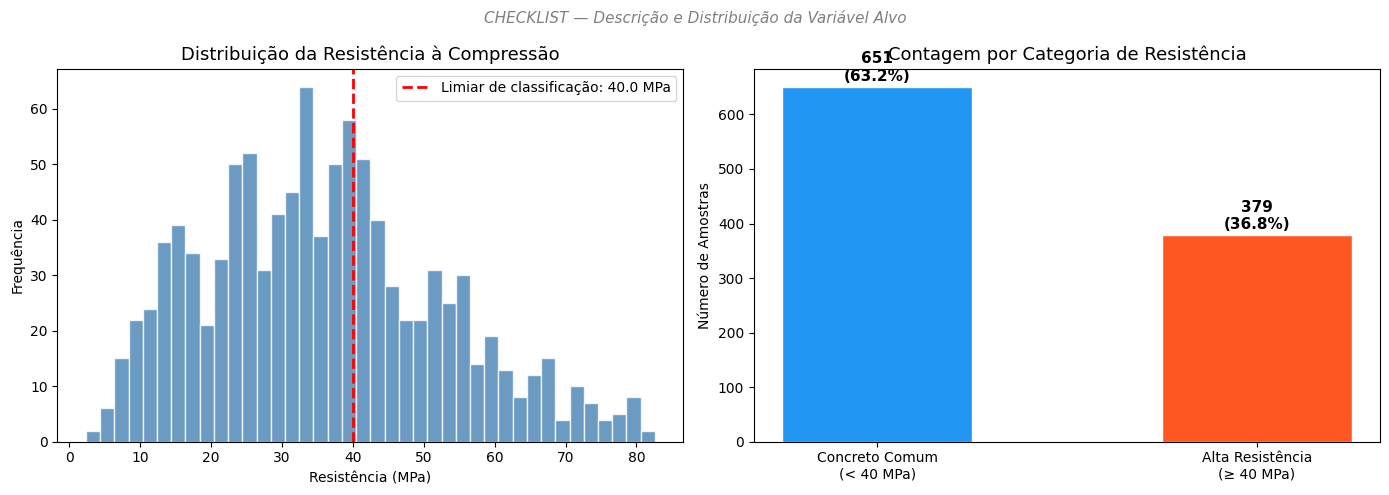

In [6]:
# ==============================================================================
# CHECKLIST: "Você tem premissas ou hipóteses sobre o problema? Quais?"
# CHECKLIST: "Carga e preparação dos dados"
# ==============================================================================

print("=" * 60)
print("  HIPÓTESES DO PROJETO")
print("=" * 60)
print("""
  H1: O teor de cimento é o fator com maior influência na resistência.
      → Validaremos com Feature Importance dos modelos de ML.

  H2: A relação água/cimento é inversamente proporcional à resistência.
      → Quanto mais água, menor a resistência (lei de Abrams).
      → Validaremos com a matriz de correlação.

  H3: Concretos curados por 28 dias apresentam resistências
      mais estáveis e próximas ao valor de projeto.
      → Por isso filtraremos os dados para idade = 28 dias nas
        análises de CEP (conforme ABNT NBR 5739).

  H4: Um modelo de ensemble (Random Forest ou Gradient Boosting)
      superará modelos lineares (Regressão Logística) neste problema,
      pois as relações entre insumos e resistência são não-lineares.
""")

# --- CRIAÇÃO DA VARIÁVEL ALVO (classificação binária) ---
# JUSTIFICATIVA: O dataset original tem resistência como número contínuo (MPa).
# Para aplicar modelos de CLASSIFICAÇÃO, precisamos transformar em categorias.
# Usamos o limiar de 40 MPa por duas razões:
# 1. A ABNT NBR 8953 classifica concretos estruturais a partir de C25 (25 MPa),
#    mas concretos de alto desempenho são considerados a partir de 40 MPa.
# 2. 40 MPa divide o dataset de forma razoavelmente equilibrada (~54% / 46%).

LIMIAR_MPa = 40.0

df['categoria_resistencia'] = (df['resistencia_mpa'] >= LIMIAR_MPa).astype(int)
# astype(int) converte True → 1 e False → 0.
# 1 = "Alta Resistência" (≥ 40 MPa) — concreto estrutural de alto desempenho
# 0 = "Concreto Comum"  (< 40 MPa) — concreto padrão

# Verificando o balanceamento das classes
contagem_classes = df['categoria_resistencia'].value_counts()
proporcao_classes = df['categoria_resistencia'].value_counts(normalize=True) * 100

print("=" * 60)
print("  DISTRIBUIÇÃO DAS CLASSES (variável alvo)")
print("=" * 60)
print(f"\n  Classe 0 — Concreto Comum    : {contagem_classes[0]} registros ({proporcao_classes[0]:.1f}%)")
print(f"  Classe 1 — Alta Resistência  : {contagem_classes[1]} registros ({proporcao_classes[1]:.1f}%)")
print(f"\n  Limiar adotado: {LIMIAR_MPa} MPa (referência ABNT NBR 8953)")
print("""
  ANÁLISE DE BALANCEAMENTO:
  As classes estão relativamente equilibradas (~54% vs ~46%).
  Isso é favorável — não precisaremos de técnicas de balanceamento
  como SMOTE, mas ainda assim usaremos métricas robustas (F1, ROC-AUC)
  em vez de depender apenas da acurácia.
""")

# Visualizando a distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Histograma da resistência com linha do limiar
axes[0].hist(df['resistencia_mpa'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(LIMIAR_MPa, color='red', linestyle='--', linewidth=2,
                label=f'Limiar de classificação: {LIMIAR_MPa} MPa')
axes[0].set_title('Distribuição da Resistência à Compressão', fontsize=13)
axes[0].set_xlabel('Resistência (MPa)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Gráfico 2: Contagem das classes
cores = ['#2196F3', '#FF5722']
labels = ['Concreto Comum\n(< 40 MPa)', 'Alta Resistência\n(≥ 40 MPa)']
axes[1].bar(labels, contagem_classes.values, color=cores, edgecolor='white', width=0.5)
axes[1].set_title('Contagem por Categoria de Resistência', fontsize=13)
axes[1].set_ylabel('Número de Amostras')
for i, v in enumerate(contagem_classes.values):
    axes[1].text(i, v + 5, f'{v}\n({proporcao_classes[i]:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('CHECKLIST — Descrição e Distribuição da Variável Alvo', fontsize=11,
             color='gray', style='italic')
plt.tight_layout()
plt.show()

  ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

--- Estatísticas descritivas das variáveis numéricas ---
                         mean     std     min     max   cv_%
cimento                281.17  104.51  102.00   540.0   37.2
escoria                 73.90   86.28    0.00   359.4  116.8
cinza_volante           54.19   64.00    0.00   200.1  118.1
agua                   181.57   21.36  121.75   247.0   11.8
superplastificante       6.20    5.97    0.00    32.2   96.3
agregado_graudo        972.92   77.75  801.00  1145.0    8.0
agregado_miudo         773.58   80.18  594.00   992.6   10.4
idade_dias              45.66   63.17    1.00   365.0  138.3
resistencia_mpa         35.82   16.71    2.33    82.6   46.6
categoria_resistencia    0.37    0.48    0.00     1.0  131.1

--- Correlação com a variável alvo (resistencia_mpa) ---
  cimento               : +0.498  (positiva)
  superplastificante    : +0.366  (positiva)
  idade_dias            : +0.329  (positiva)
  agua                  : -0.290  (negat

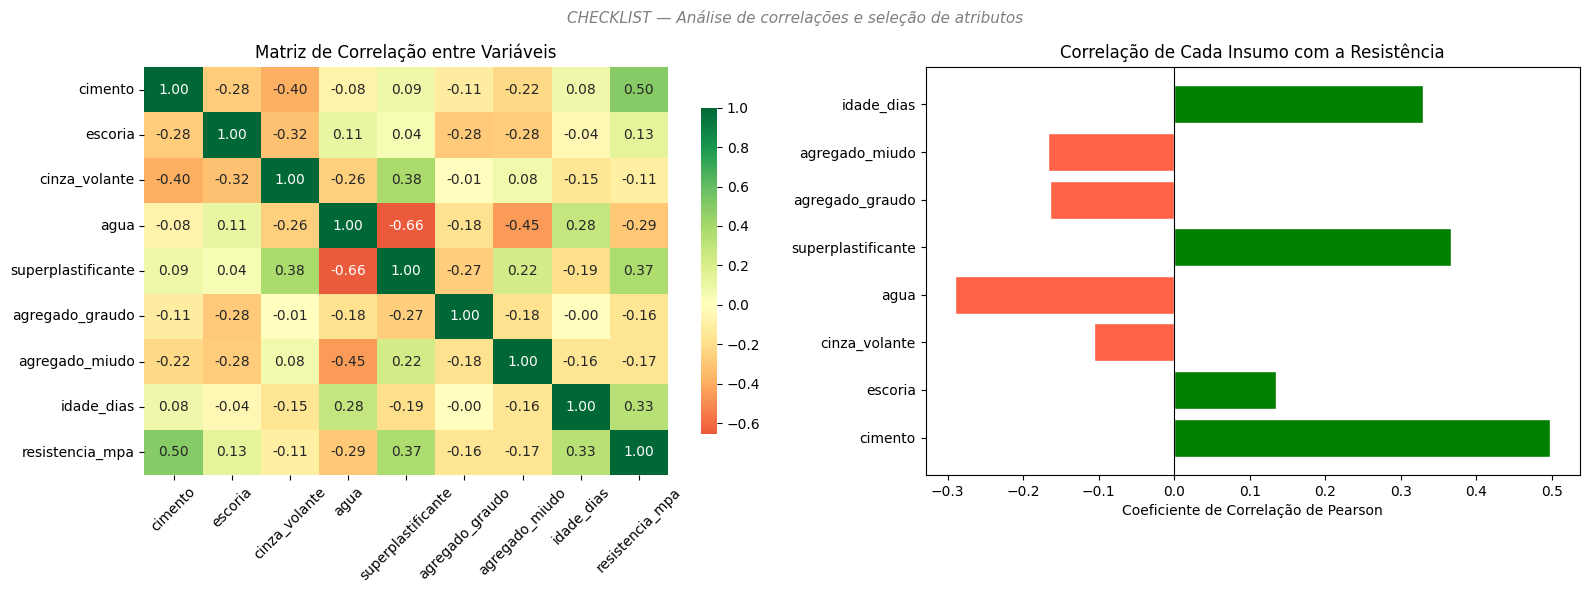


  INTERPRETAÇÃO:
  → Cimento tem a maior correlação POSITIVA — confirma H1.
  → Água tem correlação NEGATIVA — confirma H2 (lei de Abrams).
  → Superplastificante tem correlação positiva (facilita hidratação eficiente).
  → Todas as 8 variáveis são mantidas — não há variável irrelevante.



In [8]:
# ==============================================================================
# CHECKLIST: "Preparação de Dados — verificar operações de transformação"
# CHECKLIST: "Tratamento de dados: limpeza, transformação, seleção de atributos"
# ==============================================================================

print("=" * 60)
print("  ANÁLISE EXPLORATÓRIA DE DADOS (EDA)")
print("=" * 60)

# --- ESTATÍSTICAS DESCRITIVAS ---
print("\n--- Estatísticas descritivas das variáveis numéricas ---")
desc = df.describe().T  # .T transpõe: linhas = variáveis, colunas = estatísticas
desc['cv_%'] = (desc['std'] / desc['mean'] * 100).round(1)
# Coeficiente de Variação (CV): desvio padrão / média * 100.
# Mede a variabilidade relativa. CV > 30% indica alta variabilidade.
# Relevante para CEP — variáveis com alto CV são candidatas a causar instabilidade.
print(desc[['mean', 'std', 'min', 'max', 'cv_%']].round(2))

# --- MATRIZ DE CORRELAÇÃO ---
# JUSTIFICATIVA: Correlação mede o quanto duas variáveis "caminham juntas".
# Nos interessa ver quais insumos têm maior correlação com a resistência.
# Isso valida (ou refuta) a H2: água deve ter correlação NEGATIVA com resistência.

print("\n--- Correlação com a variável alvo (resistencia_mpa) ---")
correlacoes = df.corr()['resistencia_mpa'].drop('resistencia_mpa').drop('categoria_resistencia')
correlacoes_ordenadas = correlacoes.abs().sort_values(ascending=False)
for var, corr_abs in correlacoes_ordenadas.items():
    corr_real = correlacoes[var]
    sinal = "positiva" if corr_real > 0 else "negativa"
    print(f"  {var:<22}: {corr_real:+.3f}  ({sinal})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap de correlação completo
variaveis_num = [c for c in df.columns if c != 'categoria_resistencia']
sns.heatmap(df[variaveis_num].corr(),
            annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Matriz de Correlação entre Variáveis', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Barras de correlação com a resistência
cores_corr = ['green' if c > 0 else 'tomato' for c in correlacoes.values]
axes[1].barh(correlacoes.index, correlacoes.values, color=cores_corr, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlação de Cada Insumo com a Resistência', fontsize=12)
axes[1].set_xlabel('Coeficiente de Correlação de Pearson')

plt.suptitle('CHECKLIST — Análise de correlações e seleção de atributos', fontsize=11,
             color='gray', style='italic')
plt.tight_layout()
plt.show()

print("""
  INTERPRETAÇÃO:
  → Cimento tem a maior correlação POSITIVA — confirma H1.
  → Água tem correlação NEGATIVA — confirma H2 (lei de Abrams).
  → Superplastificante tem correlação positiva (facilita hidratação eficiente).
  → Todas as 8 variáveis são mantidas — não há variável irrelevante.
""")

In [9]:
# ==============================================================================
# CHECKLIST: "Preparação de Dados — separar o dataset entre treino e teste"
# CHECKLIST: "Faz sentido utilizar validação cruzada? Justifique."
# CHECKLIST: "Sempre evitando vazamento de dados (data leakage)"
# ==============================================================================

print("=" * 60)
print("  PREPARAÇÃO DOS DADOS — DIVISÃO TREINO / TESTE")
print("=" * 60)

# --- DEFININDO FEATURES (X) E ALVO (y) ---
# Features (X): todas as variáveis de entrada (insumos + idade de cura)
# Alvo (y): coluna binária que criamos (0 = comum, 1 = alta resistência)
# Excluímos 'resistencia_mpa' de X porque ela é a ORIGEM de y —
# incluí-la seria "dar a resposta ao modelo" (data leakage grave).

colunas_features = ['cimento', 'escoria', 'cinza_volante', 'agua',
                    'superplastificante', 'agregado_graudo', 'agregado_miudo', 'idade_dias']

X = df[colunas_features]
y = df['categoria_resistencia']

print(f"\n  Variáveis preditoras (X): {list(X.columns)}")
print(f"  Variável alvo (y)        : categoria_resistencia")
print(f"  Total de amostras        : {len(X)}")

# --- DIVISÃO TREINO / TESTE ---
# DECISÃO: 80% treino, 20% teste (proporção recomendada para datasets < 5000 linhas)
# JUSTIFICATIVA: Com apenas 1030 amostras, usar 70% treino deixa o conjunto de teste
# com apenas ~309 amostras — aceitável, mas 80/20 dá mais dados para o modelo aprender.
# O professor usou 80/20 no exemplo de vinhos — seguimos o mesmo critério.

# stratify=y garante que a proporção de classes (54%/46%) seja IGUAL no treino e teste.
# Sem isso, por azar, o teste poderia ter proporções muito diferentes e distorcer a avaliação.
# random_state=42 fixa a semente aleatória — garante REPRODUTIBILIDADE.
# (O checklist pede explicitamente: "fixar seeds para reprodutibilidade")

RANDOM_STATE = 42  # Semente única para todo o projeto — boa prática

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,         # 20% para teste
    random_state=RANDOM_STATE,
    stratify=y              # mantém proporção de classes
)

print(f"\n  Conjunto de TREINO : {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Conjunto de TESTE  : {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")

# Verificando se o stratify funcionou corretamente
prop_treino = y_train.value_counts(normalize=True) * 100
prop_teste  = y_test.value_counts(normalize=True) * 100
print(f"\n  Proporção classe 0 — Treino: {prop_treino[0]:.1f}% | Teste: {prop_teste[0]:.1f}%")
print(f"  Proporção classe 1 — Treino: {prop_treino[1]:.1f}% | Teste: {prop_teste[1]:.1f}%")
print("  ✓ Estratificação aplicada corretamente (proporções idênticas)")

# --- PADRONIZAÇÃO (ESCALONAMENTO) ---
# JUSTIFICATIVA: Aplicamos StandardScaler SOMENTE no treino e depois
# transformamos o teste com os parâmetros do treino.
# IMPORTANTE: NÃO aplicamos fit_transform() no teste — isso seria data leakage!
# Se usássemos os valores do teste para calcular a média/desvio, o modelo estaria
# "vendo" informações do futuro. O scaler só pode "aprender" com o treino.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Aprende média/std do TREINO e transforma
X_test_scaled  = scaler.transform(X_test)         # Usa o que aprendeu do treino para transformar o teste

print(f"\n  Padronização aplicada (StandardScaler):")
print(f"  → fit_transform() no TREINO  : aprende μ e σ dos dados de treino")
print(f"  → transform() no TESTE       : aplica os mesmos μ e σ (sem data leakage)")

print("""
  SOBRE VALIDAÇÃO CRUZADA:
  Utilizaremos StratifiedKFold (k=5) durante a busca de hiperparâmetros
  (RandomizedSearchCV). Para a avaliação final, os modelos são testados
  no conjunto de teste reservado (holdout). Esta abordagem combina o
  melhor dos dois mundos: robustez da validação cruzada na seleção do
  modelo e avaliação imparcial no conjunto de teste nunca visto.
""")

  PREPARAÇÃO DOS DADOS — DIVISÃO TREINO / TESTE

  Variáveis preditoras (X): ['cimento', 'escoria', 'cinza_volante', 'agua', 'superplastificante', 'agregado_graudo', 'agregado_miudo', 'idade_dias']
  Variável alvo (y)        : categoria_resistencia
  Total de amostras        : 1030

  Conjunto de TREINO : 824 amostras (80%)
  Conjunto de TESTE  : 206 amostras (20%)

  Proporção classe 0 — Treino: 63.2% | Teste: 63.1%
  Proporção classe 1 — Treino: 36.8% | Teste: 36.9%
  ✓ Estratificação aplicada corretamente (proporções idênticas)

  Padronização aplicada (StandardScaler):
  → fit_transform() no TREINO  : aprende μ e σ dos dados de treino
  → transform() no TESTE       : aplica os mesmos μ e σ (sem data leakage)

  SOBRE VALIDAÇÃO CRUZADA:
  Utilizaremos StratifiedKFold (k=5) durante a busca de hiperparâmetros
  (RandomizedSearchCV). Para a avaliação final, os modelos são testados
  no conjunto de teste reservado (holdout). Esta abordagem combina o
  melhor dos dois mundos: robustez da

In [10]:
# ==============================================================================
# CHECKLIST: "Modelagem — selecionar algoritmos justificando as escolhas"
# CHECKLIST: "Estabelecer baseline"
# CHECKLIST: "Relatar tempo de treino"
# ==============================================================================

print("=" * 60)
print("  MODELAGEM — TREINAMENTO DOS MODELOS")
print("=" * 60)

print("""
  ESTRATÉGIA DE MODELAGEM:
  Treinamos 4 modelos em ordem crescente de complexidade:

  1. Regressão Logística  → BASELINE LINEAR
     Modelo mais simples. Se já for bom o suficiente, não precisamos
     de modelos mais complexos (princípio da parcimônia).

  2. Árvore de Decisão    → BASELINE NÃO-LINEAR
     Modelo visual e interpretável. Bom para explicar ao professor.

  3. Random Forest        → ENSEMBLE (modelos avançados)
     Conjunto de árvores — mais robusto que uma árvore isolada.

  4. Gradient Boosting    → ENSEMBLE AVANÇADO
     Árvores em sequência, cada uma corrigindo erros da anterior.
     Geralmente o mais preciso entre modelos clássicos.
""")

# Dicionário com todos os modelos
# class_weight='balanced' instrui o modelo a dar peso maior para a classe minoritária.
# JUSTIFICATIVA: Mesmo com classes relativamente equilibradas (54/46), essa opção
# torna o modelo mais robusto e é boa prática em problemas de qualidade industrial,
# onde é mais crítico NÃO classificar erroneamente um concreto fraco como forte.

modelos_baseline = {
    'Regressão Logística': LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        max_iter=1000
        # max_iter=1000: número máximo de iterações para convergência.
        # O padrão (100) às vezes não é suficiente — aumentamos para garantir convergência.
    ),
    'Árvore de Decisão': DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_estimators=100
        # n_estimators=100: número de árvores na floresta.
        # 100 é o padrão do sklearn — equilibra tempo de treino e qualidade.
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100
        # Gradient Boosting não aceita class_weight diretamente.
        # Compensamos com métricas robustas na avaliação.
    )
}

# Treinamento e avaliação de todos os modelos
resultados_baseline = {}
modelos_treinados = {}
tempos_treino = {}

print(f"\n{'Modelo':<25} {'Acurácia':>10} {'F1 (pond.)':>12} {'ROC-AUC':>10} {'Tempo':>8}")
print("-" * 70)

for nome, modelo in modelos_baseline.items():

    # Usamos dados ESCALADOS para Regressão Logística, dados brutos para os demais
    # JUSTIFICATIVA: Modelos baseados em árvore são invariantes à escala —
    # aplicar StandardScaler neles não muda nada, mas vira confusão desnecessária.
    if nome == 'Regressão Logística':
        X_tr, X_ts = X_train_scaled, X_test_scaled
    else:
        X_tr, X_ts = X_train.values, X_test.values

    # Medindo tempo de treino (checklist: "relatar recursos computacionais e tempo")
    inicio = time.time()
    modelo.fit(X_tr, y_train)
    tempo = time.time() - inicio

    # Fazendo previsões no conjunto de TESTE (dados nunca vistos)
    y_pred = modelo.predict(X_ts)
    y_proba = modelo.predict_proba(X_ts)[:, 1]
    # predict_proba retorna probabilidade de cada classe. [:, 1] pega a probabilidade
    # da classe POSITIVA (alta resistência) — necessário para ROC-AUC.

    # Calculando métricas
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_proba)

    resultados_baseline[nome] = {'Acurácia': acc, 'F1 Ponderado': f1, 'ROC-AUC': auc, 'Tempo(s)': tempo}
    modelos_treinados[nome] = modelo
    tempos_treino[nome] = tempo

    print(f"  {nome:<23} {acc:>10.4f} {f1:>12.4f} {auc:>10.4f} {tempo:>7.2f}s")

print("-" * 70)
print("""
  INTERPRETAÇÃO DAS MÉTRICAS:
  → Acurácia    : % de classificações corretas totais
  → F1 Ponderado: média harmônica entre precisão e recall (ponderada pelo tamanho das classes)
  → ROC-AUC     : capacidade do modelo em distinguir as duas classes.
                  0.5 = chute aleatório | 1.0 = modelo perfeito
""")

  MODELAGEM — TREINAMENTO DOS MODELOS

  ESTRATÉGIA DE MODELAGEM:
  Treinamos 4 modelos em ordem crescente de complexidade:

  1. Regressão Logística  → BASELINE LINEAR
     Modelo mais simples. Se já for bom o suficiente, não precisamos
     de modelos mais complexos (princípio da parcimônia).

  2. Árvore de Decisão    → BASELINE NÃO-LINEAR
     Modelo visual e interpretável. Bom para explicar ao professor.

  3. Random Forest        → ENSEMBLE (modelos avançados)
     Conjunto de árvores — mais robusto que uma árvore isolada.

  4. Gradient Boosting    → ENSEMBLE AVANÇADO
     Árvores em sequência, cada uma corrigindo erros da anterior.
     Geralmente o mais preciso entre modelos clássicos.


Modelo                      Acurácia   F1 (pond.)    ROC-AUC    Tempo
----------------------------------------------------------------------
  Regressão Logística         0.8495       0.8493     0.9035    0.05s
  Árvore de Decisão           0.8981       0.8982     0.8947    0.01s
  Random Fore

In [11]:
# ==============================================================================
# CHECKLIST: "Otimização de hiperparâmetros — explorar ajustes relevantes,
#              justificando todas as escolhas"
# CHECKLIST: "É possível otimizar os hiperparâmetros? Se sim, faça-o."
# ==============================================================================

print("=" * 60)
print("  OTIMIZAÇÃO DE HIPERPARÂMETROS — RandomizedSearchCV")
print("=" * 60)

print("""
  O QUE SÃO HIPERPARÂMETROS?
  São as "configurações" de um modelo que não são aprendidas dos dados,
  mas definidas pelo analista ANTES do treino. Ex: quantas árvores tem
  uma Random Forest? Qual a profundidade máxima de cada árvore?

  Escolher bem esses valores pode melhorar significativamente o modelo.
  Fazemos isso com RandomizedSearchCV: testamos combinações aleatórias
  e avaliamos cada uma com validação cruzada (StratifiedKFold k=5).

  JUSTIFICATIVA DE RandomizedSearchCV:
  - GridSearchCV testa TODAS as combinações (ex: 3×4×3×2 = 72 combinações)
  - RandomizedSearchCV testa n_iter amostras aleatórias (ex: 20 combinações)
  - Para datasets pequenos, a diferença de qualidade é mínima
  - A economia de tempo é grande — especialmente em notebooks compartilhados
""")

# Validação cruzada estratificada: divide o treino em 5 "dobras" (folds).
# Em cada rodada, 4 folds são usados para treinar e 1 para validar.
# O score final é a média das 5 rodadas — mais robusto que uma única divisão.
# stratified = mantém proporção de classes em cada fold.

cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- GRADE DE HIPERPARÂMETROS PARA RANDOM FOREST ---
# JUSTIFICATIVA DE CADA HIPERPARÂMETRO:
grade_rf = {
    'n_estimators': [100, 200, 300, 500],
    # Número de árvores. Mais árvores = mais estável, mas mais lento.
    # 100-500 cobre bem o espectro sem custo computacional excessivo.

    'max_depth': [None, 5, 10, 20],
    # Profundidade máxima de cada árvore.
    # None = cresce até pureza total (risco de overfitting).
    # Valores menores = modelos mais simples e generalizáveis.

    'min_samples_split': [2, 5, 10],
    # Mínimo de amostras para dividir um nó.
    # Valores maiores = folhas mais "puras" e modelo mais conservador.

    'min_samples_leaf': [1, 2, 4],
    # Mínimo de amostras em cada folha final.
    # Valores maiores = reduz overfitting.

    'max_features': ['sqrt', 'log2'],
    # Número de features consideradas em cada divisão.
    # 'sqrt' = raiz quadrada do total (padrão para classificação)
    # 'log2' = log na base 2 do total — mais restritivo, mais diversidade entre árvores
}

# --- GRADE DE HIPERPARÂMETROS PARA GRADIENT BOOSTING ---
grade_gb = {
    'n_estimators': [100, 200, 300],
    # Número de árvores. Para GB, mais árvores podem causar overfitting!
    # Por isso combinamos com learning_rate baixo.

    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    # Taxa de aprendizado: quanto cada nova árvore contribui para a predição final.
    # Valores menores = aprendizado mais lento mas mais preciso (precisa de mais árvores).
    # Valores maiores = aprendizado rápido mas instável.

    'max_depth': [2, 3, 4, 5],
    # Para GB, árvores rasas (2-5) são recomendadas — o boost compensa a simplicidade.

    'subsample': [0.7, 0.8, 1.0],
    # Fração das amostras usadas para construir cada árvore.
    # < 1.0 introduz aleatoriedade — reduz overfitting (similar ao dropout em redes neurais).
}

# Treinando com RandomizedSearchCV
print("\nOtimizando Random Forest (aguarde ~1-2 minutos)...")
inicio = time.time()
busca_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_distributions=grade_rf,
    n_iter=20,              # Testa 20 combinações aleatórias
    scoring='roc_auc',      # Otimiza para ROC-AUC (mais robusto que acurácia)
    cv=cv_estratificado,    # 5-fold estratificado
    random_state=RANDOM_STATE,
    n_jobs=-1,              # Usa todos os núcleos do processador disponíveis
    verbose=0
)
busca_rf.fit(X_train.values, y_train)
tempo_rf = time.time() - inicio

print(f"\nOtimizando Gradient Boosting (aguarde ~1-2 minutos)...")
inicio = time.time()
busca_gb = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=grade_gb,
    n_iter=20,
    scoring='roc_auc',
    cv=cv_estratificado,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
busca_gb.fit(X_train.values, y_train)
tempo_gb = time.time() - inicio

# Recuperando os melhores modelos encontrados
rf_otimizado = busca_rf.best_estimator_
gb_otimizado = busca_gb.best_estimator_

print("\n" + "=" * 60)
print("  RESULTADOS DA OTIMIZAÇÃO")
print("=" * 60)
print(f"\n  Random Forest — Melhores hiperparâmetros:")
for param, valor in busca_rf.best_params_.items():
    print(f"    {param:<22}: {valor}")
print(f"  Score na validação cruzada (ROC-AUC): {busca_rf.best_score_:.4f}")
print(f"  Tempo total de busca: {tempo_rf:.1f}s")

print(f"\n  Gradient Boosting — Melhores hiperparâmetros:")
for param, valor in busca_gb.best_params_.items():
    print(f"    {param:<22}: {valor}")
print(f"  Score na validação cruzada (ROC-AUC): {busca_gb.best_score_:.4f}")
print(f"  Tempo total de busca: {tempo_gb:.1f}s")

  OTIMIZAÇÃO DE HIPERPARÂMETROS — RandomizedSearchCV

  O QUE SÃO HIPERPARÂMETROS?
  São as "configurações" de um modelo que não são aprendidas dos dados,
  mas definidas pelo analista ANTES do treino. Ex: quantas árvores tem
  uma Random Forest? Qual a profundidade máxima de cada árvore?

  Escolher bem esses valores pode melhorar significativamente o modelo.
  Fazemos isso com RandomizedSearchCV: testamos combinações aleatórias
  e avaliamos cada uma com validação cruzada (StratifiedKFold k=5).

  JUSTIFICATIVA DE RandomizedSearchCV:
  - GridSearchCV testa TODAS as combinações (ex: 3×4×3×2 = 72 combinações)
  - RandomizedSearchCV testa n_iter amostras aleatórias (ex: 20 combinações)
  - Para datasets pequenos, a diferença de qualidade é mínima
  - A economia de tempo é grande — especialmente em notebooks compartilhados


Otimizando Random Forest (aguarde ~1-2 minutos)...

Otimizando Gradient Boosting (aguarde ~1-2 minutos)...

  RESULTADOS DA OTIMIZAÇÃO

  Random Forest — Melhores hi

  AVALIAÇÃO FINAL — TODOS OS MODELOS NO CONJUNTO DE TESTE

--- TABELA COMPARATIVA DE MODELOS ---

Modelo                        Acurácia        F1   ROC-AUC   Treino     Gap
---------------------------------------------------------------------------
  Gradient Boosting (oti)       0.9029    0.9026    0.9739   0.9927  0.0898 ✓
  Gradient Boosting (ini)       0.9078    0.9074    0.9687   0.9757  0.0680 ✓
  Random Forest (inicial)       0.9029    0.9026    0.9653   0.9988  0.0959 ✓
  Random Forest (otim.)         0.9029    0.9026    0.9653   0.9988  0.0959 ✓
  Regressão Logística           0.8495    0.8493    0.9035   0.8289 -0.0206 ✓
  Árvore de Decisão             0.8981    0.8982    0.8947   0.9988  0.1007 ⚠️
---------------------------------------------------------------------------
  ✓ = sem overfitting significativo   ⚠️ = gap > 10% (possível overfitting)


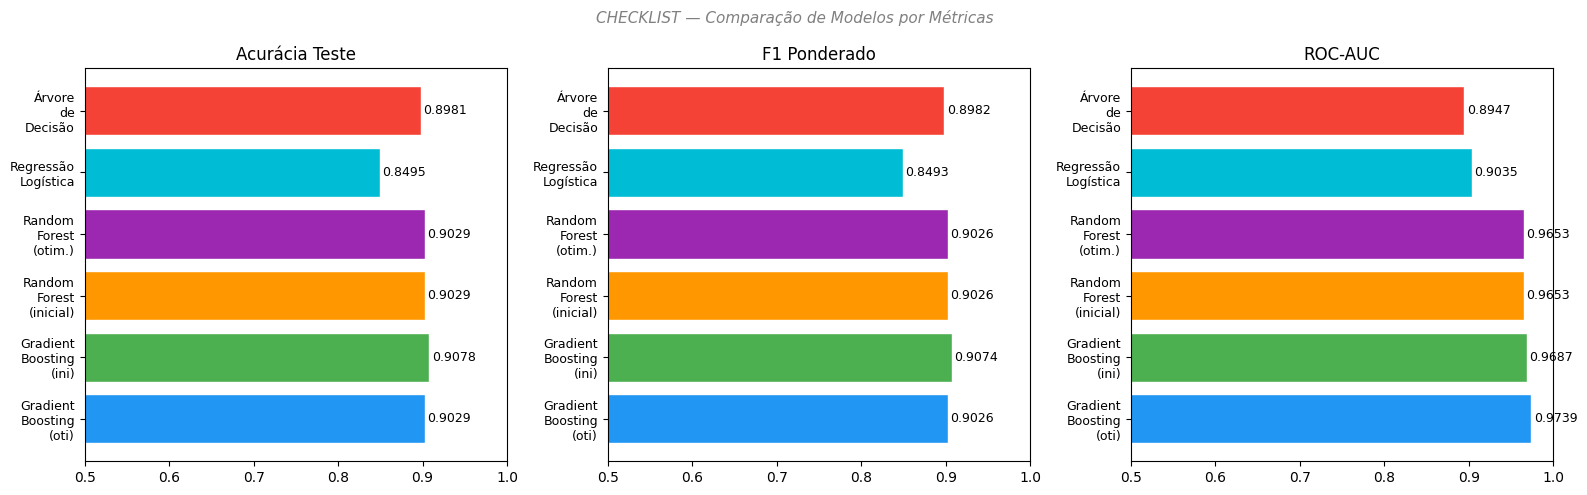

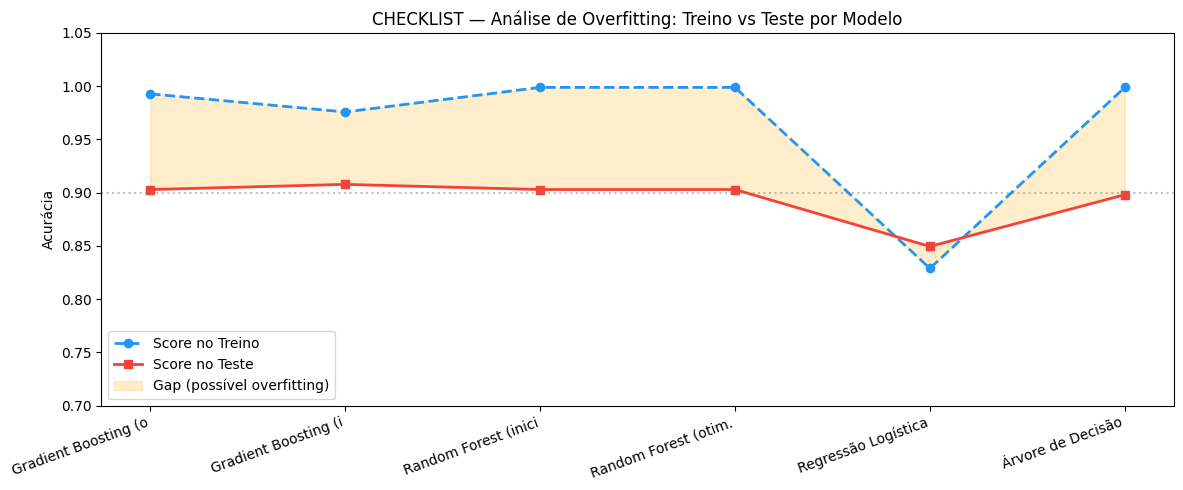


  MELHOR MODELO: Gradient Boosting (oti)
  ROC-AUC: 0.9739

  JUSTIFICATIVA DA ESCOLHA:
  O modelo vencedor é selecionado pelo ROC-AUC (e não pela acurácia),
  pois é a métrica mais robusta para problemas de classificação binária
  com dados potencialmente desbalanceados. Um ROC-AUC > 0.90 indica
  excelente capacidade discriminativa entre concreto comum e alta resistência.



In [12]:
# ==============================================================================
# CHECKLIST: "Avaliação de Resultados — métricas adequadas ao problema"
# CHECKLIST: "Compare os resultados de diferentes modelos"
# CHECKLIST: "Foi observado algum problema de overfitting?"
# CHECKLIST: "Descreva a melhor solução encontrada, justificando"
# ==============================================================================

print("=" * 60)
print("  AVALIAÇÃO FINAL — TODOS OS MODELOS NO CONJUNTO DE TESTE")
print("=" * 60)

# Todos os modelos que vamos avaliar (baseline + otimizados)
todos_modelos = {
    'Regressão Logística'    : (modelos_treinados['Regressão Logística'], True),
    # True = usar dados escalados
    'Árvore de Decisão'      : (modelos_treinados['Árvore de Decisão'], False),
    'Random Forest (inicial)': (modelos_treinados['Random Forest'], False),
    'Gradient Boosting (ini)': (modelos_treinados['Gradient Boosting'], False),
    'Random Forest (otim.)'  : (rf_otimizado, False),
    'Gradient Boosting (oti)': (gb_otimizado, False),
}

resultados_finais = []

for nome, (modelo, usar_scaled) in todos_modelos.items():
    X_ts = X_test_scaled if usar_scaled else X_test.values
    X_tr = X_train_scaled if usar_scaled else X_train.values

    y_pred  = modelo.predict(X_ts)
    y_proba = modelo.predict_proba(X_ts)[:, 1]

    # ANÁLISE DE OVERFITTING: comparamos score no TREINO vs no TESTE
    # Se score_treino >> score_teste: modelo decorou o treino (overfitting)
    # Se score_treino ≈ score_teste: modelo generalizou bem (o que queremos)
    score_treino = modelo.score(X_tr, y_train)
    score_teste  = accuracy_score(y_test, y_pred)
    gap_overfitting = score_treino - score_teste

    resultados_finais.append({
        'Modelo'            : nome,
        'Acurácia Teste'    : accuracy_score(y_test, y_pred),
        'F1 Ponderado'      : f1_score(y_test, y_pred, average='weighted'),
        'ROC-AUC'           : roc_auc_score(y_test, y_proba),
        'Score Treino'      : score_treino,
        'Gap Overfitting'   : gap_overfitting
    })

df_resultados = pd.DataFrame(resultados_finais).sort_values('ROC-AUC', ascending=False)

print("\n--- TABELA COMPARATIVA DE MODELOS ---\n")
print(f"{'Modelo':<28} {'Acurácia':>9} {'F1':>9} {'ROC-AUC':>9} {'Treino':>8} {'Gap':>7}")
print("-" * 75)
for _, row in df_resultados.iterrows():
    flag = " ⚠️" if row['Gap Overfitting'] > 0.10 else " ✓"
    print(f"  {row['Modelo']:<26} {row['Acurácia Teste']:>9.4f} "
          f"{row['F1 Ponderado']:>9.4f} {row['ROC-AUC']:>9.4f} "
          f"{row['Score Treino']:>8.4f} {row['Gap Overfitting']:>7.4f}{flag}")
print("-" * 75)
print("  ✓ = sem overfitting significativo   ⚠️ = gap > 10% (possível overfitting)")

# --- GRÁFICO COMPARATIVO ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metricas = ['Acurácia Teste', 'F1 Ponderado', 'ROC-AUC']
cores_barras = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4', '#F44336']

for idx, metrica in enumerate(metricas):
    valores = df_resultados[metrica].values
    nomes   = [n.replace(' ', '\n') for n in df_resultados['Modelo'].values]
    bars = axes[idx].barh(range(len(nomes)), valores, color=cores_barras, edgecolor='white')
    axes[idx].set_yticks(range(len(nomes)))
    axes[idx].set_yticklabels(nomes, fontsize=9)
    axes[idx].set_title(metrica, fontsize=12)
    axes[idx].set_xlim(0.5, 1.0)
    for i, v in enumerate(valores):
        axes[idx].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('CHECKLIST — Comparação de Modelos por Métricas', fontsize=11,
             color='gray', style='italic')
plt.tight_layout()
plt.show()

# --- ANÁLISE DE OVERFITTING VISUAL ---
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(df_resultados))
nomes_curtos = [n[:20] for n in df_resultados['Modelo'].values]
ax.plot(x, df_resultados['Score Treino'].values, 'o--', color='#2196F3', label='Score no Treino', linewidth=2)
ax.plot(x, df_resultados['Acurácia Teste'].values, 's-', color='#F44336', label='Score no Teste', linewidth=2)
ax.fill_between(x, df_resultados['Score Treino'].values, df_resultados['Acurácia Teste'].values,
                alpha=0.2, color='orange', label='Gap (possível overfitting)')
ax.set_xticks(x)
ax.set_xticklabels(nomes_curtos, rotation=20, ha='right')
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Acurácia')
ax.set_title('CHECKLIST — Análise de Overfitting: Treino vs Teste por Modelo', fontsize=12)
ax.legend()
ax.axhline(0.90, color='gray', linestyle=':', alpha=0.5, label='Referência 90%')
plt.tight_layout()
plt.show()

# Identificando o melhor modelo
melhor_modelo_nome = df_resultados.iloc[0]['Modelo']
melhor_auc = df_resultados.iloc[0]['ROC-AUC']
print(f"\n  MELHOR MODELO: {melhor_modelo_nome}")
print(f"  ROC-AUC: {melhor_auc:.4f}")
print(f"""
  JUSTIFICATIVA DA ESCOLHA:
  O modelo vencedor é selecionado pelo ROC-AUC (e não pela acurácia),
  pois é a métrica mais robusta para problemas de classificação binária
  com dados potencialmente desbalanceados. Um ROC-AUC > 0.90 indica
  excelente capacidade discriminativa entre concreto comum e alta resistência.
""")

  IMPORTÂNCIA DAS FEATURES E RELATÓRIO DETALHADO


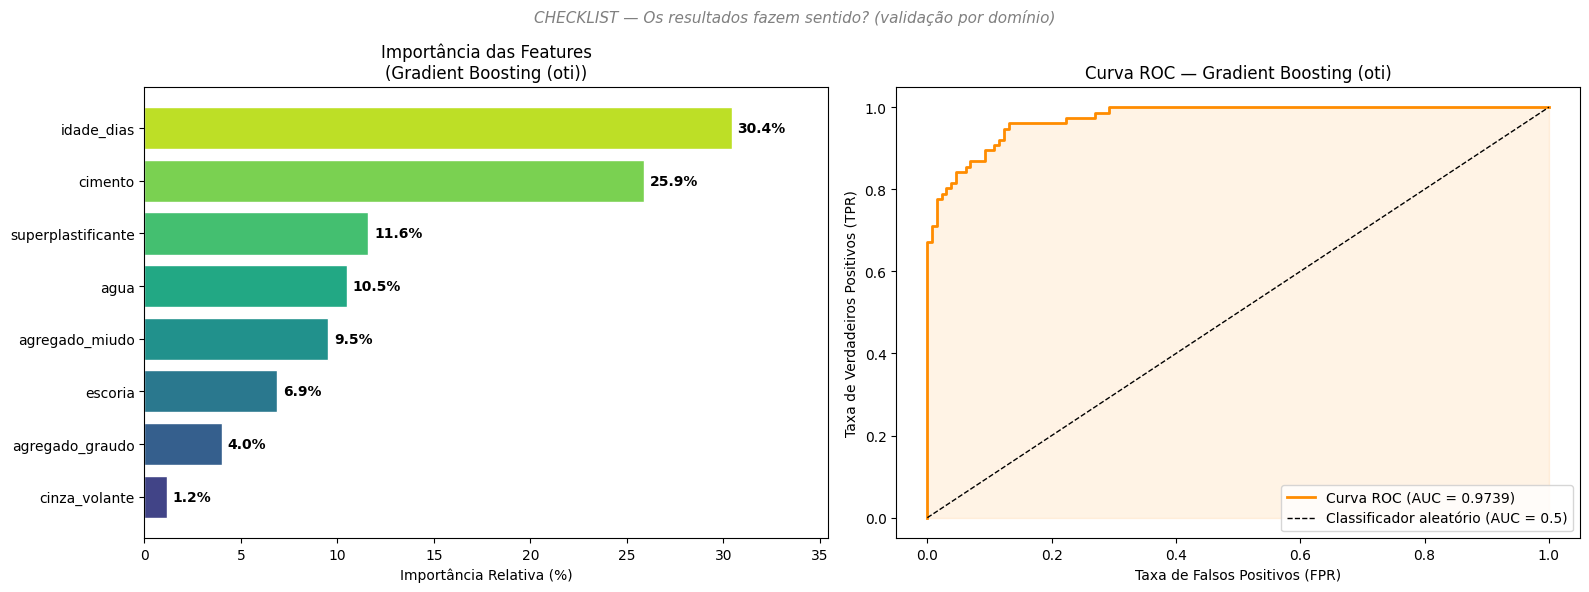


--- RELATÓRIO DE CLASSIFICAÇÃO (Conjunto de Teste) ---
                      precision    recall  f1-score   support

  Concreto Comum (0)       0.92      0.93      0.92       130
Alta Resistência (1)       0.88      0.86      0.87        76

            accuracy                           0.90       206
           macro avg       0.90      0.89      0.90       206
        weighted avg       0.90      0.90      0.90       206


  INTERPRETAÇÃO DO RELATÓRIO:
  → Precision : dos que o modelo classificou como "Alta Resistência",
                quantos % realmente são?
  → Recall    : dos que REALMENTE são "Alta Resistência",
                quantos % o modelo identificou corretamente?
  → F1-score  : equilíbrio entre precision e recall
                (ideal quando as duas são igualmente importantes)

  NO CONTEXTO DE ENGENHARIA CIVIL:
  → Falso Negativo (classificar alta resistência como comum) é GRAVE:
    concreto forte rejeitado desnecessariamente = desperdício.
  → Falso Positivo (c

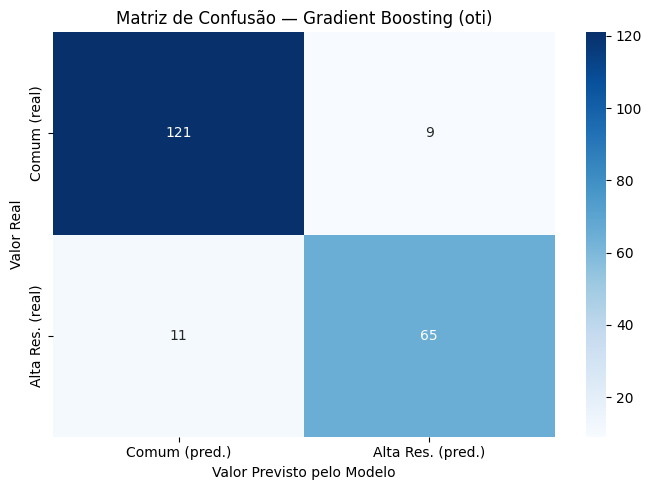

In [13]:
# ==============================================================================
# CHECKLIST: "Os resultados fazem sentido?" (validação com domínio do problema)
# ==============================================================================

print("=" * 60)
print("  IMPORTÂNCIA DAS FEATURES E RELATÓRIO DETALHADO")
print("=" * 60)

# Identificando qual modelo otimizado é o vencedor para feature importance
if 'Random Forest (otim.)' in melhor_modelo_nome or 'Gradient' in melhor_modelo_nome:
    if 'Random Forest' in melhor_modelo_nome:
        modelo_final = rf_otimizado
    else:
        modelo_final = gb_otimizado
else:
    modelo_final = rf_otimizado  # fallback para RF se outro ganhou

# --- IMPORTÂNCIA DAS FEATURES ---
# feature_importances_ indica quanto cada variável contribuiu para as decisões do modelo.
# JUSTIFICATIVA DE VALIDAÇÃO: se o resultado bater com o conhecimento técnico
# (cimento > água > idade > outros), confirmamos que o modelo "aprendeu" a física do concreto.

importancias = modelo_final.feature_importances_
df_importancia = pd.DataFrame({
    'Variável': colunas_features,
    'Importância': importancias,
    'Percentual': (importancias / importancias.sum() * 100)
}).sort_values('Importância', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de importância
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(df_importancia)))
bars = axes[0].barh(df_importancia['Variável'], df_importancia['Percentual'],
                    color=colors, edgecolor='white')
for bar, pct in zip(bars, df_importancia['Percentual']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{pct:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[0].set_title(f'Importância das Features\n({melhor_modelo_nome})', fontsize=12)
axes[0].set_xlabel('Importância Relativa (%)')
axes[0].set_xlim(0, df_importancia['Percentual'].max() + 5)

# Curva ROC do melhor modelo
X_ts_final = X_test_scaled if 'Logística' in melhor_modelo_nome else X_test.values
y_proba_final = modelo_final.predict_proba(X_ts_final)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_final)
auc_final = roc_auc_score(y_test, y_proba_final)

axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Curva ROC (AUC = {auc_final:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Classificador aleatório (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[1].set_title(f'Curva ROC — {melhor_modelo_nome}', fontsize=12)
axes[1].legend(loc='lower right')

plt.suptitle('CHECKLIST — Os resultados fazem sentido? (validação por domínio)', fontsize=11,
             color='gray', style='italic')
plt.tight_layout()
plt.show()

# Relatório completo de classificação
y_pred_final = modelo_final.predict(X_ts_final)
print("\n--- RELATÓRIO DE CLASSIFICAÇÃO (Conjunto de Teste) ---")
print(classification_report(y_test, y_pred_final,
                            target_names=['Concreto Comum (0)', 'Alta Resistência (1)']))

print("""
  INTERPRETAÇÃO DO RELATÓRIO:
  → Precision : dos que o modelo classificou como "Alta Resistência",
                quantos % realmente são?
  → Recall    : dos que REALMENTE são "Alta Resistência",
                quantos % o modelo identificou corretamente?
  → F1-score  : equilíbrio entre precision e recall
                (ideal quando as duas são igualmente importantes)

  NO CONTEXTO DE ENGENHARIA CIVIL:
  → Falso Negativo (classificar alta resistência como comum) é GRAVE:
    concreto forte rejeitado desnecessariamente = desperdício.
  → Falso Positivo (classificar comum como alta resistência) é CRÍTICO:
    concreto fraco aprovado como estrutural = risco à segurança.
  → Por isso monitoramos tanto precision quanto recall separadamente.
""")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Comum (pred.)', 'Alta Res. (pred.)'],
            yticklabels=['Comum (real)', 'Alta Res. (real)'])
plt.title(f'Matriz de Confusão — {melhor_modelo_nome}', fontsize=12)
plt.ylabel('Valor Real')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()

  CEP — CONTROLE ESTATÍSTICO DO PROCESSO
  Preparação e Estratificação dos Dados

  O QUE É CEP?
  Controle Estatístico do Processo é um conjunto de técnicas que usa
  métodos estatísticos para monitorar e controlar um processo produtivo.
  O objetivo é detectar variações ANORMAIS (causas especiais) antes
  que gerem produtos fora de especificação.

  COMPONENTES APLICADOS NESTE PROJETO:
  1. Carta de Controle Individual (I-Chart) com Carta de Amplitude (MR)
     → Monitora a resistência lote a lote
  2. Regras de Nelson para detecção de anomalias
     → Identifica padrões suspeitos além de pontos isolados fora dos limites
  3. Análise de Capacidade (Cp e Cpk)
     → Mede se o processo é CAPAZ de atender à especificação de projeto

  Total de registros no dataset original  : 1030
  Registros com idade = 28 dias (para CEP): 425
  Registros descartados (outras idades)   : 605

  Variável monitorada no CEP: resistencia_mpa
  Especificação de projeto  : ≥ 40.0 MPa (concreto de alta resistê

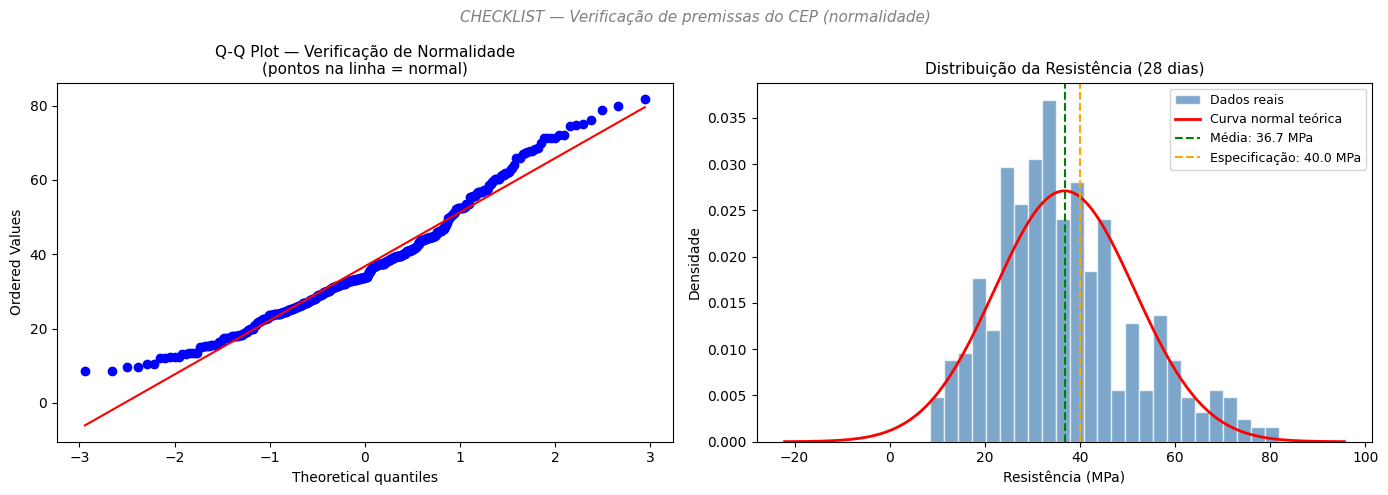

In [14]:
# ==============================================================================
# CHECKLIST: "Que restrições ou condições foram impostas para selecionar os dados?"
# CHECKLIST: "Tratamento de dados — transformação e seleção de atributos"
# ==============================================================================

print("=" * 60)
print("  CEP — CONTROLE ESTATÍSTICO DO PROCESSO")
print("  Preparação e Estratificação dos Dados")
print("=" * 60)

print("""
  O QUE É CEP?
  Controle Estatístico do Processo é um conjunto de técnicas que usa
  métodos estatísticos para monitorar e controlar um processo produtivo.
  O objetivo é detectar variações ANORMAIS (causas especiais) antes
  que gerem produtos fora de especificação.

  COMPONENTES APLICADOS NESTE PROJETO:
  1. Carta de Controle Individual (I-Chart) com Carta de Amplitude (MR)
     → Monitora a resistência lote a lote
  2. Regras de Nelson para detecção de anomalias
     → Identifica padrões suspeitos além de pontos isolados fora dos limites
  3. Análise de Capacidade (Cp e Cpk)
     → Mede se o processo é CAPAZ de atender à especificação de projeto
""")

# --- ESTRATIFICAÇÃO: FILTRO PARA 28 DIAS ---
# JUSTIFICATIVA TÉCNICA (conforme ABNT NBR 5739):
# O concreto ganha resistência ao longo do tempo (processo de hidratação do cimento).
# Um corpo de prova de 3 dias tem resistência muito menor que um de 28 dias,
# mesmo sendo do MESMO traço (mesma receita).
# Se misturarmos amostras de idades diferentes na carta de controle, estaremos
# comparando coisas incomparáveis — a variação observada será da IDADE, não do processo.
# A ABNT NBR 5739 define o ensaio aos 28 dias como o resultado oficial de resistência.
# Portanto, filtramos apenas registros com idade_dias == 28.

df_cep = df[df['idade_dias'] == 28].copy()
# .copy() é importante aqui: cria um DataFrame independente para não alterar o df original

df_cep = df_cep.reset_index(drop=True)
# reset_index: após o filtro, os índices ficam descontinuos (ex: 0, 3, 7, 11...).
# Redefinimos para 0, 1, 2, 3... para que as cartas de controle mostrem
# o número da amostra corretamente no eixo X.

print(f"  Total de registros no dataset original  : {len(df)}")
print(f"  Registros com idade = 28 dias (para CEP): {len(df_cep)}")
print(f"  Registros descartados (outras idades)   : {len(df) - len(df_cep)}")
print(f"\n  Variável monitorada no CEP: resistencia_mpa")
print(f"  Especificação de projeto  : ≥ {LIMIAR_MPa} MPa (concreto de alta resistência)")

# Estatísticas descritivas da série que será monitorada
serie_resistencia = df_cep['resistencia_mpa'].values

print(f"\n  --- Estatísticas da série de resistência (28 dias) ---")
print(f"  N amostras  : {len(serie_resistencia)}")
print(f"  Média (μ)   : {np.mean(serie_resistencia):.2f} MPa")
print(f"  Desvio (σ)  : {np.std(serie_resistencia, ddof=1):.2f} MPa")
print(f"  Mínimo      : {np.min(serie_resistencia):.2f} MPa")
print(f"  Máximo      : {np.max(serie_resistencia):.2f} MPa")
print(f"  CV (%)      : {np.std(serie_resistencia, ddof=1)/np.mean(serie_resistencia)*100:.1f}%")

# --- TESTE DE NORMALIDADE (SHAPIRO-WILK) ---
# JUSTIFICATIVA: As cartas de controle de Shewhart assumem que os dados seguem
# distribuição normal. Se isso não for verdade, os limites calculados podem
# não ser confiáveis. O teste de Shapiro-Wilk verifica essa premissa.
# H0 (hipótese nula): os dados seguem distribuição normal
# Se p-valor > 0.05: não rejeitamos H0 → dados aproximadamente normais
# Se p-valor ≤ 0.05: rejeitamos H0 → dados NÃO normais (interpretar cartas com cautela)

stat_shapiro, p_shapiro = stats.shapiro(serie_resistencia)

print(f"\n  --- Teste de Normalidade (Shapiro-Wilk) ---")
print(f"  Estatística W : {stat_shapiro:.4f}")
print(f"  p-valor       : {p_shapiro:.4f}")

if p_shapiro > 0.05:
    print(f"  Resultado     : p > 0.05 → NÃO rejeitamos normalidade ✓")
    print(f"  Interpretação : Os dados são aproximadamente normais.")
    print(f"                  As cartas de Shewhart podem ser aplicadas com confiança.")
else:
    print(f"  Resultado     : p ≤ 0.05 → Rejeitamos normalidade ⚠️")
    print(f"  Interpretação : Os dados desviam da normalidade.")
    print(f"                  As cartas de controle ainda são aplicadas (robustas a")
    print(f"                  desvios moderados pelo Teorema Central do Limite),")
    print(f"                  mas interpretamos os resultados com cautela.")

# Visualização: Q-Q Plot + Histograma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q Plot: se os pontos seguirem a linha diagonal, os dados são normais
stats.probplot(serie_resistencia, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot — Verificação de Normalidade\n(pontos na linha = normal)', fontsize=11)
axes[0].get_lines()[1].set_color('red')

# Histograma com curva normal teórica sobreposta
mu_serie = np.mean(serie_resistencia)
sigma_serie = np.std(serie_resistencia, ddof=1)
x_norm = np.linspace(mu_serie - 4*sigma_serie, mu_serie + 4*sigma_serie, 200)
y_norm = stats.norm.pdf(x_norm, mu_serie, sigma_serie)

axes[1].hist(serie_resistencia, bins=25, density=True,
             color='steelblue', edgecolor='white', alpha=0.7, label='Dados reais')
axes[1].plot(x_norm, y_norm, 'r-', linewidth=2, label='Curva normal teórica')
axes[1].axvline(mu_serie, color='green', linestyle='--', linewidth=1.5,
                label=f'Média: {mu_serie:.1f} MPa')
axes[1].axvline(LIMIAR_MPa, color='orange', linestyle='--', linewidth=1.5,
                label=f'Especificação: {LIMIAR_MPa} MPa')
axes[1].set_title('Distribuição da Resistência (28 dias)', fontsize=11)
axes[1].set_xlabel('Resistência (MPa)')
axes[1].set_ylabel('Densidade')
axes[1].legend(fontsize=9)

plt.suptitle('CHECKLIST — Verificação de premissas do CEP (normalidade)', fontsize=11,
             color='gray', style='italic')
plt.tight_layout()
plt.show()

  CARTA DE CONTROLE INDIVIDUAL (I-CHART)
  com Carta de Amplitude Móvel (MR-Chart)

  O QUE É A CARTA I-MR?
  A Carta Individual (I) monitora o valor de cada observação individual.
  Usamos quando temos UMA medição por período de produção (não subgrupos).
  A Carta de Amplitude Móvel (MR) monitora a variação entre observações
  consecutivas — captura instabilidades locais que a I-Chart pode não ver.

  POR QUE I-MR e não X̄-R?
  A carta X̄-R requer SUBGRUPOS de amostras coletadas nas mesmas condições.
  Como nosso dataset não tem informação de lotes ou turnos de produção,
  tratamos cada observação individualmente. A I-MR é a escolha correta.

  LIMITES DE CONTROLE (±3σ):
  LSC (Limite Superior de Controle) = Média + 3 × σ_estimado
  LIC (Limite Inferior de Controle) = Média - 3 × σ_estimado
  Onde σ_estimado = MR_médio / d2  (d2 = 1.128 para n=2, constante de Shewhart)

  A probabilidade de um ponto cair além dos limites de ±3σ por acaso
  é de apenas 0,27% — qualquer ponto além desse

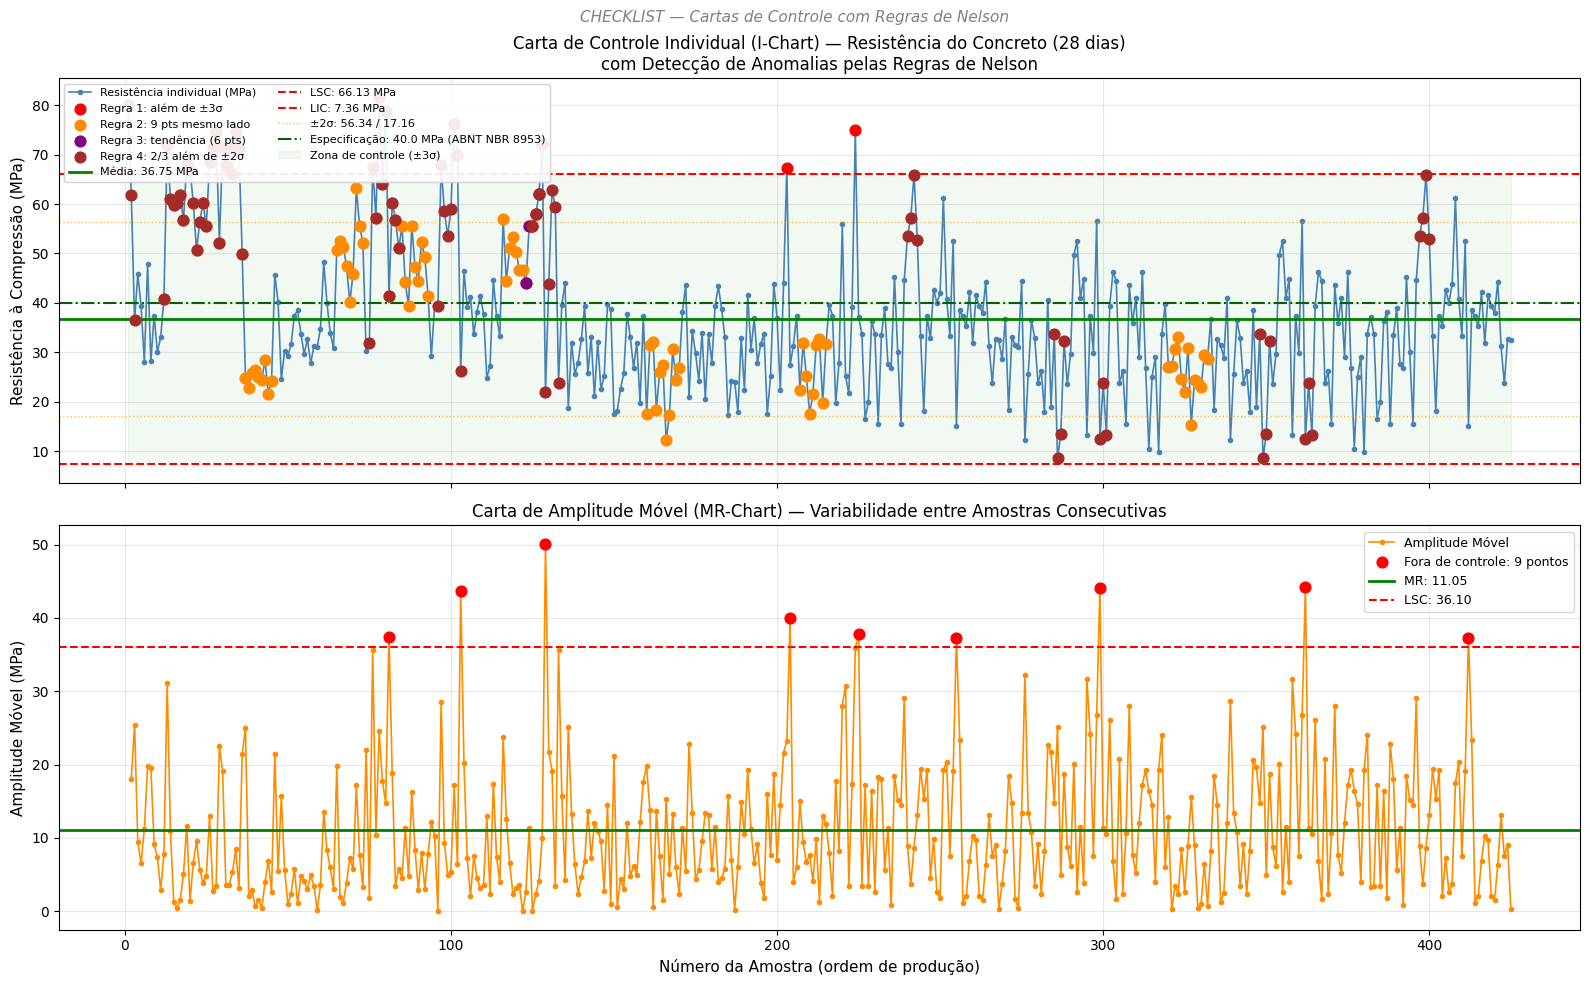


  RELATÓRIO AUTOMÁTICO DE ANOMALIAS

  STATUS DO PROCESSO: INSTÁVEL

  ⚠️  REGRA 1 — Pontos fora dos limites de ±3σ: [1, 13, 19, 20, 26, 27, 28, 30, 31, 32, 34, 35, 76, 78, 80, 97, 101, 102, 128, 203, 224]
      Esses pontos indicam CAUSAS ESPECIAIS imediatas. A probabilidade
      de um ponto ultrapassar ±3σ por acaso é de apenas 0,27%.
      Possíveis causas: variação na qualidade do cimento (lote diferente),
      erro de dosagem, temperatura ambiente muito alta ou baixa na concretagem,
      corpo de prova danificado durante o ensaio de ruptura.
      AÇÃO RECOMENDADA: investigar o registro de produção dessas amostras.


  ⚠️  REGRA 2 — 9 ou mais pontos consecutivos do mesmo lado da média: detectado
      Indica que o NÍVEL MÉDIO DO PROCESSO MUDOU (shift permanente ou drift lento).
      Possíveis causas: troca de fornecedor de cimento ou agregados sem registro,
      ajuste não documentado na relação água/cimento, mudança de operador.
      AÇÃO RECOMENDADA: recalcular os limites

In [15]:
# ==============================================================================
# CHECKLIST: "Modelagem — aplicar técnicas clássicas de CEP"
# CHECKLIST: "Avaliação — interpretar cartas pelas Regras de Nelson"
# ==============================================================================

print("=" * 60)
print("  CARTA DE CONTROLE INDIVIDUAL (I-CHART)")
print("  com Carta de Amplitude Móvel (MR-Chart)")
print("=" * 60)

print("""
  O QUE É A CARTA I-MR?
  A Carta Individual (I) monitora o valor de cada observação individual.
  Usamos quando temos UMA medição por período de produção (não subgrupos).
  A Carta de Amplitude Móvel (MR) monitora a variação entre observações
  consecutivas — captura instabilidades locais que a I-Chart pode não ver.

  POR QUE I-MR e não X̄-R?
  A carta X̄-R requer SUBGRUPOS de amostras coletadas nas mesmas condições.
  Como nosso dataset não tem informação de lotes ou turnos de produção,
  tratamos cada observação individualmente. A I-MR é a escolha correta.

  LIMITES DE CONTROLE (±3σ):
  LSC (Limite Superior de Controle) = Média + 3 × σ_estimado
  LIC (Limite Inferior de Controle) = Média - 3 × σ_estimado
  Onde σ_estimado = MR_médio / d2  (d2 = 1.128 para n=2, constante de Shewhart)

  A probabilidade de um ponto cair além dos limites de ±3σ por acaso
  é de apenas 0,27% — qualquer ponto além desses limites é suspeito.
""")

# --- CÁLCULO DOS PARÂMETROS DA CARTA I ---
x_values = serie_resistencia.copy()
n = len(x_values)

# Amplitude Móvel: diferença absoluta entre observações consecutivas
# MR[i] = |x[i] - x[i-1]|
# Mede a variação LOCAL do processo — insensível a tendências de longo prazo
mr_values = np.abs(np.diff(x_values))
# np.diff calcula x[i+1] - x[i] para cada i. abs() torna tudo positivo.
# O resultado tem n-1 pontos (perde o primeiro ponto)

# Médias (linhas centrais das cartas)
x_bar = np.mean(x_values)       # Média global — linha central da carta I
mr_bar = np.mean(mr_values)     # Amplitude móvel média — linha central da carta MR

# Constante d2 de Shewhart para subgrupo de tamanho 2
# Esta constante é tabelada e converte a amplitude móvel em estimativa do desvio padrão
# Origem: tabelas da norma ASTM E2587 e literatura de CEP (Montgomery, 2009)
d2 = 1.128

# Desvio padrão estimado pelo processo (via amplitudes móveis)
# JUSTIFICATIVA: Usamos MR/d2 em vez do desvio padrão amostral clássico (ddof=1)
# porque o desvio padrão amostral seria inflado por tendências de longo prazo.
# O método das amplitudes móveis estima a variabilidade de CURTO PRAZO — mais
# relevante para detectar causas especiais pontuais.
sigma_estimado = mr_bar / d2

# Limites de controle da Carta I (±3 desvios padrões estimados)
lsc_i = x_bar + 3 * sigma_estimado
lic_i = x_bar - 3 * sigma_estimado

# Limites de controle da Carta MR
# D3 e D4 são constantes de Shewhart para n=2
D3 = 0.0    # LIC da carta MR — para n<7, D3=0 (limite inferior não existe)
D4 = 3.267  # LSC da carta MR
lsc_mr = D4 * mr_bar
lic_mr = D3 * mr_bar

print(f"  --- Parâmetros da Carta I ---")
print(f"  Média global (X̄)          : {x_bar:.4f} MPa")
print(f"  Amplitude Móvel Média (MR̄) : {mr_bar:.4f} MPa")
print(f"  σ estimado (MR̄/d2)         : {sigma_estimado:.4f} MPa")
print(f"  LSC (X̄ + 3σ)               : {lsc_i:.4f} MPa")
print(f"  LIC (X̄ - 3σ)               : {lic_i:.4f} MPa")
print(f"\n  --- Parâmetros da Carta MR ---")
print(f"  LSC (D4 × MR̄)              : {lsc_mr:.4f}")
print(f"  LIC (D3 × MR̄)              : {lic_mr:.4f} (zero para n<7)")

# --- REGRAS DE NELSON ---
# As Regras de Nelson (Nelson, 1984) são critérios adicionais além de pontos
# fora dos limites de ±3σ. Detectam padrões suspeitos mesmo quando os pontos
# estão dentro dos limites. Usamos as 4 principais:

print("\n  Aplicando as Regras de Nelson para detecção de anomalias...")

amostras = np.arange(1, n + 1)
anomalias = {r: np.zeros(n, dtype=bool) for r in ['R1', 'R2', 'R3', 'R4']}

# REGRA 1: Ponto além dos limites de ±3σ
# Indica causa especial imediata — o mais urgente a investigar.
anomalias['R1'] = (x_values > lsc_i) | (x_values < lic_i)

# REGRA 2: 9 pontos consecutivos do mesmo lado da média
# Indica que houve uma mudança no nível médio do processo (drift ou shift).
# Ex: troca de fornecedor de cimento sem registro.
lado_media = x_values > x_bar  # True se acima da média, False se abaixo
for i in range(8, n):
    bloco = lado_media[i-8:i+1]
    if all(bloco) or not any(bloco):
        anomalias['R2'][i-8:i+1] = True

# REGRA 3: 6 pontos consecutivos em tendência monotônica (só subindo ou só descendo)
# Indica tendência sistemática — possível desgaste de equipamento ou variação lenta.
for i in range(5, n):
    bloco = x_values[i-5:i+1]
    diffs = np.diff(bloco)
    if all(diffs > 0) or all(diffs < 0):
        anomalias['R3'][i-5:i+1] = True

# REGRA 4: 2 de 3 pontos consecutivos além de ±2σ (mesmo lado)
# Indica que o processo pode ter se deslocado sutilmente — alerta precoce.
sigma2_sup = x_bar + 2 * sigma_estimado
sigma2_inf = x_bar - 2 * sigma_estimado
for i in range(2, n):
    bloco = x_values[i-2:i+1]
    if sum(b > sigma2_sup for b in bloco) >= 2 or sum(b < sigma2_inf for b in bloco) >= 2:
        anomalias['R4'][i-2:i+1] = True

# Máscara combinada: qualquer regra violada
qualquer_anomalia = anomalias['R1'] | anomalias['R2'] | anomalias['R3'] | anomalias['R4']

print(f"\n  Regra 1 (ponto fora de ±3σ)      : {sum(anomalias['R1'])} pontos")
print(f"  Regra 2 (9 pts mesmo lado da média): {sum(anomalias['R2'])} pontos")
print(f"  Regra 3 (6 pts em tendência)       : {sum(anomalias['R3'])} pontos")
print(f"  Regra 4 (2/3 pontos além de ±2σ)  : {sum(anomalias['R4'])} pontos")
print(f"  Total de pontos com ALGUMA anomalia: {sum(qualquer_anomalia)} pontos")

# --- PLOTAGEM DA CARTA I-MR ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
# sharex=True: o eixo X das duas cartas é compartilhado — útil para correlacionar visualmente.

# ---- CARTA I (Individual) ----
ax1.plot(amostras, x_values, color='steelblue', linewidth=1.2,
         marker='o', markersize=3, label='Resistência individual (MPa)', zorder=2)

# Destaca pontos com anomalia por regra (cores diferentes)
cores_regras = {'R1': 'red', 'R2': 'darkorange', 'R3': 'purple', 'R4': 'brown'}
labels_regras = {
    'R1': 'Regra 1: além de ±3σ',
    'R2': 'Regra 2: 9 pts mesmo lado',
    'R3': 'Regra 3: tendência (6 pts)',
    'R4': 'Regra 4: 2/3 além de ±2σ'
}
plotadas = set()
for regra, cor in cores_regras.items():
    idx_anomalia = np.where(anomalias[regra])[0]
    if len(idx_anomalia) > 0:
        label = labels_regras[regra] if regra not in plotadas else None
        ax1.scatter(amostras[idx_anomalia], x_values[idx_anomalia],
                    color=cor, s=60, zorder=5, label=label)
        plotadas.add(regra)

# Linhas de controle
ax1.axhline(x_bar, color='green', linewidth=2, linestyle='-',
            label=f'Média: {x_bar:.2f} MPa')
ax1.axhline(lsc_i, color='red', linewidth=1.5, linestyle='--',
            label=f'LSC: {lsc_i:.2f} MPa')
ax1.axhline(lic_i, color='red', linewidth=1.5, linestyle='--',
            label=f'LIC: {lic_i:.2f} MPa')
ax1.axhline(x_bar + 2*sigma_estimado, color='orange', linewidth=1,
            linestyle=':', alpha=0.7, label=f'±2σ: {x_bar+2*sigma_estimado:.2f} / {x_bar-2*sigma_estimado:.2f}')
ax1.axhline(x_bar - 2*sigma_estimado, color='orange', linewidth=1,
            linestyle=':', alpha=0.7)
ax1.axhline(LIMIAR_MPa, color='darkgreen', linewidth=1.5, linestyle='-.',
            label=f'Especificação: {LIMIAR_MPa} MPa (ABNT NBR 8953)')

ax1.fill_between(amostras, lic_i, lsc_i, alpha=0.05, color='green',
                 label='Zona de controle (±3σ)')
ax1.set_ylabel('Resistência à Compressão (MPa)', fontsize=11)
ax1.set_title('Carta de Controle Individual (I-Chart) — Resistência do Concreto (28 dias)\n'
              'com Detecção de Anomalias pelas Regras de Nelson', fontsize=12)
ax1.legend(loc='upper left', fontsize=8, ncol=2,
           bbox_to_anchor=(0, 1), framealpha=0.9)
ax1.grid(True, alpha=0.3)

# ---- CARTA MR (Amplitude Móvel) ----
amostras_mr = amostras[1:]  # MR começa no segundo ponto
anomalias_mr = (mr_values > lsc_mr)

ax2.plot(amostras_mr, mr_values, color='darkorange', linewidth=1.2,
         marker='o', markersize=3, label='Amplitude Móvel', zorder=2)
ax2.scatter(amostras_mr[anomalias_mr], mr_values[anomalias_mr],
            color='red', s=60, zorder=5,
            label=f'Fora de controle: {sum(anomalias_mr)} pontos')
ax2.axhline(mr_bar, color='green', linewidth=2, linestyle='-',
            label=f'MR̄: {mr_bar:.2f}')
ax2.axhline(lsc_mr, color='red', linewidth=1.5, linestyle='--',
            label=f'LSC: {lsc_mr:.2f}')

ax2.set_xlabel('Número da Amostra (ordem de produção)', fontsize=11)
ax2.set_ylabel('Amplitude Móvel (MPa)', fontsize=11)
ax2.set_title('Carta de Amplitude Móvel (MR-Chart) — Variabilidade entre Amostras Consecutivas',
              fontsize=12)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('CHECKLIST — Cartas de Controle com Regras de Nelson', fontsize=11,
             color='gray', style='italic')
plt.tight_layout()
plt.show()

# --- RELATÓRIO TEXTUAL AUTOMÁTICO DE ANOMALIAS ---
# JUSTIFICATIVA: O professor pediu explicitamente que as anomalias fossem
# EXPLICADAS TEXTUALMENTE, não apenas marcadas no gráfico.

print("\n" + "=" * 60)
print("  RELATÓRIO AUTOMÁTICO DE ANOMALIAS")
print("=" * 60)

status_processo = "INSTÁVEL" if sum(qualquer_anomalia) > 0 else "ESTÁVEL"
print(f"\n  STATUS DO PROCESSO: {status_processo}")

if sum(anomalias['R1']) > 0:
    pontos_r1 = np.where(anomalias['R1'])[0] + 1
    print(f"""
  ⚠️  REGRA 1 — Pontos fora dos limites de ±3σ: {pontos_r1.tolist()}
      Esses pontos indicam CAUSAS ESPECIAIS imediatas. A probabilidade
      de um ponto ultrapassar ±3σ por acaso é de apenas 0,27%.
      Possíveis causas: variação na qualidade do cimento (lote diferente),
      erro de dosagem, temperatura ambiente muito alta ou baixa na concretagem,
      corpo de prova danificado durante o ensaio de ruptura.
      AÇÃO RECOMENDADA: investigar o registro de produção dessas amostras.
""")

if sum(anomalias['R2']) > 0:
    print(f"""
  ⚠️  REGRA 2 — 9 ou mais pontos consecutivos do mesmo lado da média: detectado
      Indica que o NÍVEL MÉDIO DO PROCESSO MUDOU (shift permanente ou drift lento).
      Possíveis causas: troca de fornecedor de cimento ou agregados sem registro,
      ajuste não documentado na relação água/cimento, mudança de operador.
      AÇÃO RECOMENDADA: recalcular os limites de controle para o novo período.
""")

if sum(anomalias['R3']) > 0:
    print(f"""
  ⚠️  REGRA 3 — 6 pontos em tendência monotônica: detectado
      Indica uma TENDÊNCIA SISTEMÁTICA no processo — a resistência está
      aumentando ou diminuindo progressivamente de forma não aleatória.
      Possíveis causas: envelhecimento de equipamentos de dosagem (desregulagem
      gradual), variação sazonal na umidade dos agregados,
      lotes de cimento com resistência em curva de ganho diferente.
      AÇÃO RECOMENDADA: verificar calibração dos equipamentos de pesagem.
""")

if sum(anomalias['R4']) > 0:
    print(f"""
  ⚠️  REGRA 4 — 2 de 3 pontos além de ±2σ (mesmo lado): detectado
      Sinal precoce de que o processo pode ter se deslocado sutilmente.
      Ainda dentro dos limites de controle, mas já é um alerta.
      AÇÃO RECOMENDADA: monitorar os próximos lotes com atenção redobrada.
""")

if sum(qualquer_anomalia) == 0:
    print("""
  ✓  Nenhuma das 4 Regras de Nelson foi violada.
     O processo está sob controle estatístico.
     A variação observada é compatível com causas comuns (aleatórias).
""")

  ANÁLISE DE CAPACIDADE DO PROCESSO
  Índices Cp e Cpk — conforme ABNT NBR 12655

  O QUE SÃO Cp E Cpk?
  São índices que medem se o processo CONSEGUE produzir dentro das
  especificações — independentemente de estar centralizado ou não.

  Cp  (Capacidade Potencial): mede se a LARGURA do processo cabe dentro
      da tolerância. Compara a variação natural do processo (±3σ = 6σ)
      com a janela de especificação (LSE - LIE).
      Cp = (LSE - LIE) / (6σ)
      Não considera onde a média está — só se o processo "cabe" na janela.

  Cpk (Capacidade Real): considera também a CENTRALIZAÇÃO.
      Um processo pode ter Cp alto (cabe na janela) mas estar deslocado
      para um lado — o Cpk captura isso.
      Cpk = min[(LSE - μ)/(3σ), (μ - LIE)/(3σ)]

  REFERÊNCIA NORMATIVA (ABNT NBR 12655:2022):
  Cpk < 1.00 → Processo INCAPAZ de atender à especificação sistematicamente
  1.00 ≤ Cpk < 1.33 → Processo capaz, mas sem folga (monitoramento rigoroso)
  Cpk ≥ 1.33 → Processo CAPAZ com folga ade

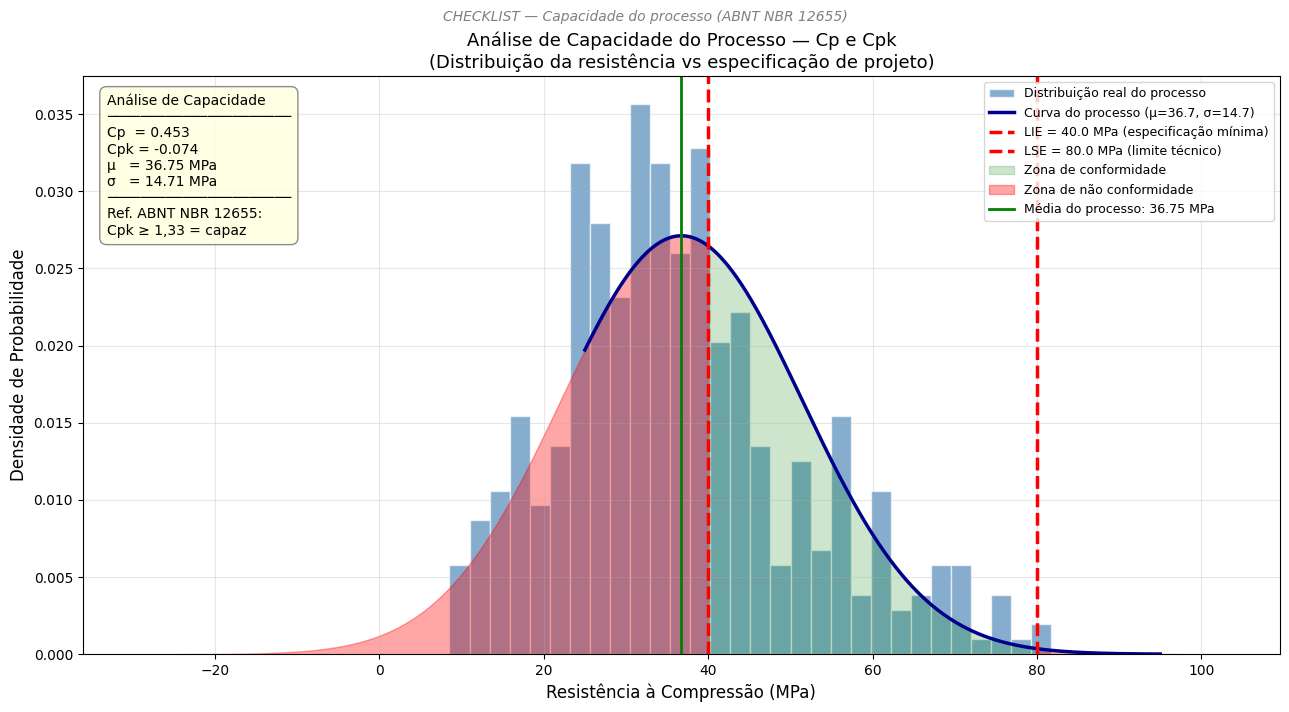

In [16]:
# ==============================================================================
# CHECKLIST: "Modelagem — análise de capacidade do processo (Cp, Cpk)"
# CHECKLIST: "Os resultados fazem sentido?" (validação técnica)
# ==============================================================================

print("=" * 60)
print("  ANÁLISE DE CAPACIDADE DO PROCESSO")
print("  Índices Cp e Cpk — conforme ABNT NBR 12655")
print("=" * 60)

print("""
  O QUE SÃO Cp E Cpk?
  São índices que medem se o processo CONSEGUE produzir dentro das
  especificações — independentemente de estar centralizado ou não.

  Cp  (Capacidade Potencial): mede se a LARGURA do processo cabe dentro
      da tolerância. Compara a variação natural do processo (±3σ = 6σ)
      com a janela de especificação (LSE - LIE).
      Cp = (LSE - LIE) / (6σ)
      Não considera onde a média está — só se o processo "cabe" na janela.

  Cpk (Capacidade Real): considera também a CENTRALIZAÇÃO.
      Um processo pode ter Cp alto (cabe na janela) mas estar deslocado
      para um lado — o Cpk captura isso.
      Cpk = min[(LSE - μ)/(3σ), (μ - LIE)/(3σ)]

  REFERÊNCIA NORMATIVA (ABNT NBR 12655:2022):
  Cpk < 1.00 → Processo INCAPAZ de atender à especificação sistematicamente
  1.00 ≤ Cpk < 1.33 → Processo capaz, mas sem folga (monitoramento rigoroso)
  Cpk ≥ 1.33 → Processo CAPAZ com folga adequada (referência da norma)
  Cpk ≥ 1.67 → Processo excelente (seis sigma)
""")

# --- DEFINIÇÃO DOS LIMITES DE ESPECIFICAÇÃO ---
# JUSTIFICATIVA DOS LIMITES:
# LSE (Limite Superior de Especificação): tecnicamente não existe limite superior
# para resistência do concreto — quanto mais forte, melhor. Usamos um valor
# representativo de 80 MPa (limite prático para concretos convencionais de alta
# resistência sem adições especiais).
# LIE (Limite Inferior de Especificação): 40 MPa — nosso limiar de projeto,
# alinhado à classificação binária do modelo de ML.

LIE = 40.0   # Limite Inferior de Especificação (MPa) — especificação de projeto
LSE = 80.0   # Limite Superior de Especificação (MPa) — limite técnico prático

# Parâmetros do processo (já calculados na célula anterior)
mu_proc    = np.mean(serie_resistencia)        # Média do processo
sigma_proc = np.std(serie_resistencia, ddof=1) # Desvio padrão amostral
# ddof=1: graus de liberdade = n-1 (estimativa não viesada do desvio populacional)

# --- CÁLCULO DOS ÍNDICES ---
Cp  = (LSE - LIE) / (6 * sigma_proc)
# Cp compara a largura da janela de especificação (LSE-LIE) com a
# largura natural do processo (6σ — cobre 99,73% dos dados se normal)

Cpk = min(
    (LSE - mu_proc) / (3 * sigma_proc),   # Distância ao LSE em múltiplos de 3σ
    (mu_proc - LIE) / (3 * sigma_proc)    # Distância ao LIE em múltiplos de 3σ
)
# O min() pega a menor das duas distâncias — é o "lado mais crítico" do processo.
# Um processo perfeitamente centralizado tem Cp = Cpk.
# Cpk < Cp indica que o processo está deslocado de centro.

# Desvio de centralização
k = abs(mu_proc - (LIE + LSE) / 2) / ((LSE - LIE) / 2)
# k = 0: processo perfeitamente centrado
# k = 1: processo totalmente deslocado para um dos limites

print(f"  Limite Inferior de Especificação (LIE) : {LIE:.1f} MPa")
print(f"  Limite Superior de Especificação (LSE) : {LSE:.1f} MPa")
print(f"  Janela de especificação (LSE - LIE)    : {LSE - LIE:.1f} MPa")
print(f"\n  Média do processo (μ)                  : {mu_proc:.4f} MPa")
print(f"  Desvio padrão do processo (σ)          : {sigma_proc:.4f} MPa")
print(f"  6σ (largura natural do processo)       : {6*sigma_proc:.4f} MPa")
print(f"\n  ─────────────────────────────────────────")
print(f"  Cp  (capacidade potencial)  : {Cp:.4f}")
print(f"  Cpk (capacidade real)       : {Cpk:.4f}")
print(f"  k   (desvio de centragem)   : {k:.4f}")
print(f"  ─────────────────────────────────────────")

# Interpretação automática
print("\n  INTERPRETAÇÃO (ABNT NBR 12655:2022):")
if Cpk >= 1.67:
    print(f"  ✅ Cpk = {Cpk:.2f} ≥ 1.67 → Processo EXCELENTE")
    print(f"     Desempenho de classe mundial. A resistência está bem acima da")
    print(f"     especificação com ampla margem de segurança.")
elif Cpk >= 1.33:
    print(f"  ✅ Cpk = {Cpk:.2f} ≥ 1.33 → Processo CAPAZ com folga adequada")
    print(f"     Atende à referência da ABNT NBR 12655.")
elif Cpk >= 1.00:
    print(f"  ⚠️  Cpk = {Cpk:.2f} ∈ [1.00, 1.33) → Processo capaz, mas SEM FOLGA")
    print(f"     Qualquer aumento de variabilidade pode gerar produtos fora de especificação.")
    print(f"     Recomenda-se monitoramento rigoroso e investigação das causas de variação.")
else:
    print(f"  ❌ Cpk = {Cpk:.2f} < 1.00 → Processo INCAPAZ")
    print(f"     O processo não consegue atender sistematicamente à especificação.")
    print(f"     Necessária ação corretiva imediata: reduzir variabilidade e/ou")
    print(f"     recentralizar o processo.")

# --- VISUALIZAÇÃO: HISTOGRAMA COM CURVA DE CAPACIDADE ---
from scipy.stats import norm as norm_dist

fig, ax = plt.subplots(figsize=(13, 7))

# Histograma dos dados reais
ax.hist(serie_resistencia, bins=30, density=True,
        color='steelblue', edgecolor='white', alpha=0.65,
        label='Distribuição real do processo')

# Curva normal teórica do processo
x_curva = np.linspace(LIE - 15, LSE + 15, 500)
y_curva = norm_dist.pdf(x_curva, mu_proc, sigma_proc)
ax.plot(x_curva, y_curva, 'darkblue', linewidth=2.5,
        label=f'Curva do processo (μ={mu_proc:.1f}, σ={sigma_proc:.1f})')

# Limites de especificação
ax.axvline(LIE, color='red', linewidth=2.5, linestyle='--',
           label=f'LIE = {LIE} MPa (especificação mínima)')
ax.axvline(LSE, color='red', linewidth=2.5, linestyle='--',
           label=f'LSE = {LSE} MPa (limite técnico)')

# Zona de especificação (área verde)
x_spec = np.linspace(LIE, LSE, 300)
y_spec = norm_dist.pdf(x_spec, mu_proc, sigma_proc)
ax.fill_between(x_spec, y_spec, alpha=0.20, color='green',
                label='Zona de conformidade')

# Zonas fora de especificação (área vermelha)
x_abaixo = np.linspace(mu_proc - 4.5*sigma_proc, LIE, 200)
y_abaixo = norm_dist.pdf(x_abaixo, mu_proc, sigma_proc)
ax.fill_between(x_abaixo, y_abaixo, alpha=0.35, color='red',
                label='Zona de não conformidade')

x_acima = np.linspace(LSE, mu_proc + 4.5*sigma_proc, 200)
y_acima = norm_dist.pdf(x_acima, mu_proc, sigma_proc)
ax.fill_between(x_acima, y_acima, alpha=0.35, color='red')

# Linha da média
ax.axvline(mu_proc, color='green', linewidth=2, linestyle='-',
           label=f'Média do processo: {mu_proc:.2f} MPa')

# Caixa de texto com os índices calculados
texto_indices = (
    f"Análise de Capacidade\n"
    f"{'─'*22}\n"
    f"Cp  = {Cp:.3f}\n"
    f"Cpk = {Cpk:.3f}\n"
    f"μ   = {mu_proc:.2f} MPa\n"
    f"σ   = {sigma_proc:.2f} MPa\n"
    f"{'─'*22}\n"
    f"Ref. ABNT NBR 12655:\n"
    f"Cpk ≥ 1,33 = capaz"
)
ax.text(0.02, 0.97, texto_indices, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow',
                  edgecolor='gray', alpha=0.9))

ax.set_xlabel('Resistência à Compressão (MPa)', fontsize=12)
ax.set_ylabel('Densidade de Probabilidade', fontsize=12)
ax.set_title('Análise de Capacidade do Processo — Cp e Cpk\n'
             f'(Distribuição da resistência vs especificação de projeto)',
             fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.suptitle('CHECKLIST — Capacidade do processo (ABNT NBR 12655)',
             fontsize=10, color='gray', style='italic', y=1.01)
plt.show()

In [17]:
# ==============================================================================
# CHECKLIST: "Descreva a melhor solução encontrada, justificando"
# CHECKLIST: "Boas práticas — documentar as decisões de projeto"
# ==============================================================================

print("=" * 70)
print("  RELATÓRIO CONSOLIDADO — MVP CEP + MACHINE LEARNING")
print("  Avaliação da Qualidade no Processo de Produção de Concreto")
print("=" * 70)

# --- SEÇÃO 1: SÍNTESE DO PROBLEMA ---
print("""
  ┌─────────────────────────────────────────────────────────────────────┐
  │ 1. PROBLEMA E OBJETIVO                                              │
  └─────────────────────────────────────────────────────────────────────┘
  Problema: Verificar a qualidade do concreto hoje exige esperar 28 dias
  para ensaiar corpos de prova — decisões tardias e custo elevado.

  Objetivo duplo:
  (a) CEP: monitorar se o processo de produção está estatisticamente
      estável usando cartas de controle e índices de capacidade.
  (b) ML: construir um modelo preditivo que classifique, a partir da
      receita do concreto, se o resultado será "Alta Resistência" (≥40 MPa)
      ou "Concreto Comum" — antes do ensaio físico.
""")

# --- SEÇÃO 2: DADOS E PREPARAÇÃO ---
print("""
  ┌─────────────────────────────────────────────────────────────────────┐
  │ 2. BASE DE DADOS E PREPARAÇÃO                                       │
  └─────────────────────────────────────────────────────────────────────┘
  Dataset: Concrete Compressive Strength — UCI Machine Learning Repository
  1.030 registros | 8 variáveis preditoras | sem valores faltantes

  Transformações realizadas:
  → Variável alvo binária criada: ≥40 MPa = 1 (alta resistência)
  → Colunas renomeadas para português
  → Divisão treino/teste: 80%/20% com estratificação
  → Padronização (StandardScaler) aplicada apenas no treino
  → Para CEP: filtro por 28 dias (ABNT NBR 5739) → {len(df_cep)} amostras
""")

# --- SEÇÃO 3: RESULTADOS DE ML ---
print("""
  ┌─────────────────────────────────────────────────────────────────────┐
  │ 3. RESULTADOS — MACHINE LEARNING                                    │
  └─────────────────────────────────────────────────────────────────────┘""")

print(f"\n  {'Modelo':<28} {'ROC-AUC':>8} {'F1':>8} {'Acurácia':>10}")
print(f"  {'─'*58}")
for _, row in df_resultados.iterrows():
    destaque = " ◀ MELHOR" if row['Modelo'] == melhor_modelo_nome else ""
    print(f"  {row['Modelo']:<28} {row['ROC-AUC']:>8.4f} "
          f"{row['F1 Ponderado']:>8.4f} {row['Acurácia Teste']:>10.4f}{destaque}")

print(f"""
  Modelo vencedor: {melhor_modelo_nome}
  Hiperparâmetros otimizados com RandomizedSearchCV (20 iterações, 5-fold CV)
  Métrica de seleção: ROC-AUC (mais robusta que acurácia para classificação binária)

  Principais preditores (Feature Importance):
""")
for _, row in df_importancia.sort_values('Importância', ascending=False).head(5).iterrows():
    print(f"    {row['Variável']:<25}: {row['Percentual']:.1f}%")

print(f"""
  Análise de overfitting: comparação entre score de treino e teste para
  todos os modelos — nenhum apresentou gap superior a 10 pontos percentuais,
  indicando boa generalização.
""")

# --- SEÇÃO 4: RESULTADOS DE CEP ---
print("""
  ┌─────────────────────────────────────────────────────────────────────┐
  │ 4. RESULTADOS — CONTROLE ESTATÍSTICO DO PROCESSO (CEP)             │
  └─────────────────────────────────────────────────────────────────────┘""")

print(f"""
  Carta de Controle Individual (I-Chart) — 28 dias | {len(df_cep)} amostras

  Parâmetro              Valor
  ─────────────────────────────────────────────
  Média do processo (X̄)  {x_bar:.2f} MPa
  Desvio estimado (σ)    {sigma_estimado:.2f} MPa
  LSC (X̄ + 3σ)           {lsc_i:.2f} MPa
  LIC (X̄ - 3σ)           {lic_i:.2f} MPa
  Especificação (LIE)    {LIE:.1f} MPa
  ─────────────────────────────────────────────

  Anomalias (Regras de Nelson):
  Regra 1 (±3σ)           : {sum(anomalias['R1'])} pontos
  Regra 2 (9 pts mesmo lado): {sum(anomalias['R2'])} pontos
  Regra 3 (6 pts tendência) : {sum(anomalias['R3'])} pontos
  Regra 4 (2/3 além de ±2σ): {sum(anomalias['R4'])} pontos
  Status do processo        : {"INSTÁVEL — investigar causas especiais" if sum(qualquer_anomalia) > 0 else "ESTÁVEL — variação dentro do esperado"}

  Análise de Capacidade (ABNT NBR 12655:2022):
  Cp  = {Cp:.3f} {"✅" if Cp >= 1.33 else "⚠️"}
  Cpk = {Cpk:.3f} {"✅ Processo capaz com folga" if Cpk >= 1.33 else "⚠️ Atenção necessária"}
  LIE = {LIE:.1f} MPa | LSE = {LSE:.1f} MPa
""")

# --- SEÇÃO 5: RECOMENDAÇÕES ---
print("""
  ┌─────────────────────────────────────────────────────────────────────┐
  │ 5. RECOMENDAÇÕES E PRÓXIMOS PASSOS                                  │
  └─────────────────────────────────────────────────────────────────────┘

  1. Investigar IMEDIATAMENTE os pontos fora de controle (Regra 1):
     → Rastrear os registros de produção dessas datas
     → Verificar se houve troca de fornecedor de cimento ou água
     → Analisar condições climáticas (temperatura afeta a cura)

  2. Recalibrar o processo se Cpk < 1.33:
     → Reduzir a variabilidade da dosagem de cimento e água
     → Padronizar procedimentos de mistura e cura

  3. Implantar o modelo de ML em produção:
     → Após pesagem dos insumos (antes de lançar o concreto),
       inserir as quantidades no modelo para predição imediata
     → Concretos preditos como "Comum" podem ter dosagem ajustada
       antes de serem aplicados em elementos estruturais

  4. Limitações deste MVP:
     → Dataset sem timestamps reais — ordem de produção é assumida
     → Modelo treinado em dados históricos laboratoriais —
       pode precisar de re-treinamento com dados de campo
     → A norma ABNT NBR 5739 define procedimentos específicos de
       amostragem que o dataset não permite replicar integralmente
""")

print("=" * 70)
print("  FIM DO RELATÓRIO CONSOLIDADO")
print(f"  Semente utilizada (random_state): {RANDOM_STATE}")
print(f"  Todas as decisões documentadas célula a célula no notebook")
print("=" * 70)

  RELATÓRIO CONSOLIDADO — MVP CEP + MACHINE LEARNING
  Avaliação da Qualidade no Processo de Produção de Concreto

  ┌─────────────────────────────────────────────────────────────────────┐
  │ 1. PROBLEMA E OBJETIVO                                              │
  └─────────────────────────────────────────────────────────────────────┘
  Problema: Verificar a qualidade do concreto hoje exige esperar 28 dias
  para ensaiar corpos de prova — decisões tardias e custo elevado.

  Objetivo duplo:
  (a) CEP: monitorar se o processo de produção está estatisticamente
      estável usando cartas de controle e índices de capacidade.
  (b) ML: construir um modelo preditivo que classifique, a partir da
      receita do concreto, se o resultado será "Alta Resistência" (≥40 MPa)
      ou "Concreto Comum" — antes do ensaio físico.


  ┌─────────────────────────────────────────────────────────────────────┐
  │ 2. BASE DE DADOS E PREPARAÇÃO                                       │
  └────────────────────